
===== FITTED SIR-H PARAMETERS =====
beta0 = 1.378700
k     = 0.079200
I0    = 0.522093
eta   = 0.006086

===== GROWTH DIAGNOSTICS =====
Recent slope       = 0.133333
Exponential growth = 0.449981
SIR-H weight       = 0.05

===== 5-WEEK FORECAST =====
Week 10: Hosp=0.8216 [0.7643, 0.9135]
Week 11: Hosp=1.1331 [0.9812, 1.3613]
Week 12: Hosp=1.5864 [1.2573, 2.1115]
Week 13: Hosp=2.2629 [1.5988, 3.3311]
Week 14: Hosp=3.2909 [2.0672, 5.4240]


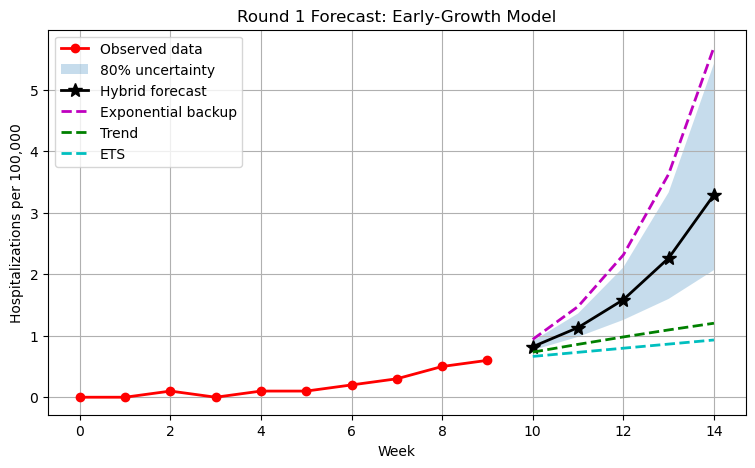

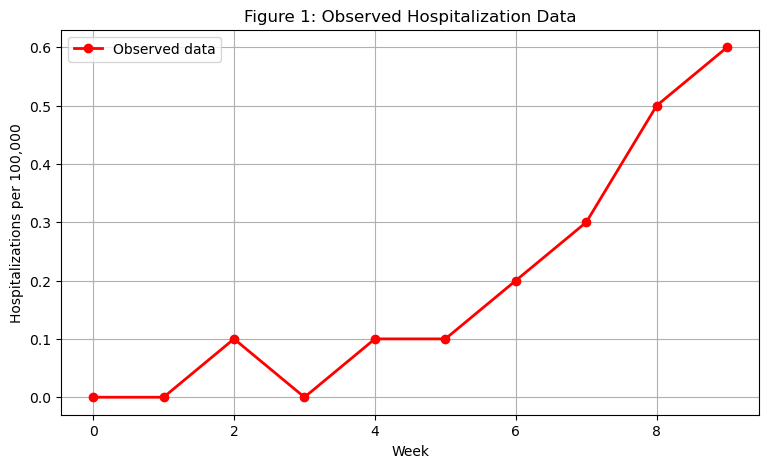

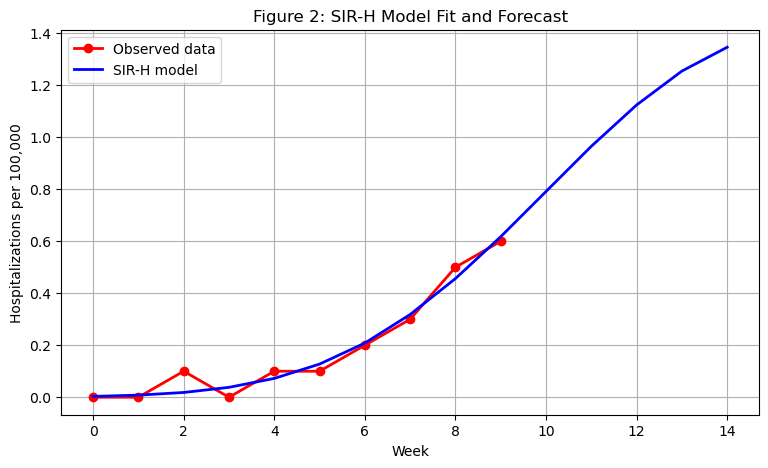

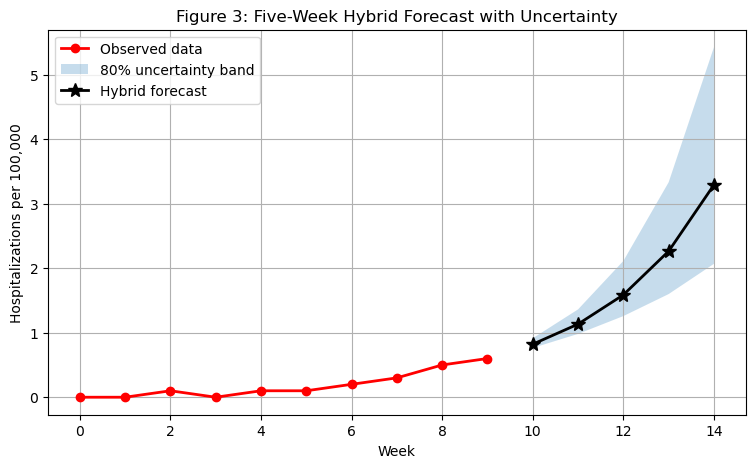

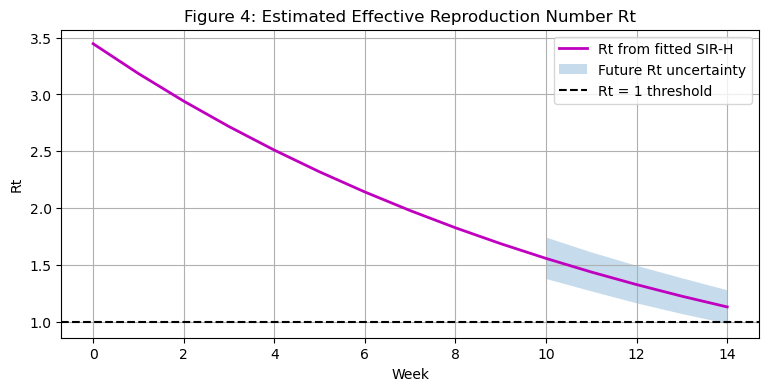

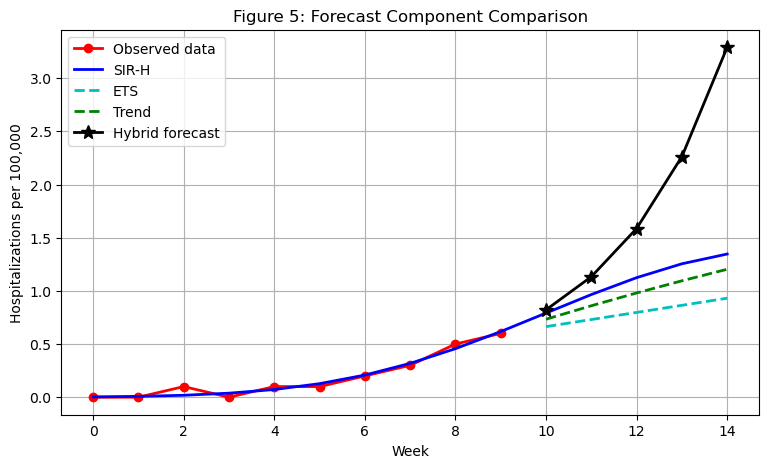


All files and report figures generated successfully.

Round 1 forecast files generated successfully.


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from statsmodels.tsa.holtwinters import ExponentialSmoothing

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\sample1.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 5
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)
all_weeks = np.concatenate([week, future_weeks])

# ============================================================
# SETTINGS
# ============================================================

N = 100000
gamma = 1 / 2.5

sirh_perturbation = 0.08
ets_perturbation = 0.12
trend_perturbation = 0.15
exp_perturbation = 0.20

forecast_floor = 0.01

# ============================================================
# SIR-H MODEL
# ============================================================

def sirh_rhs(t, y, beta0, k):
    S, I, R = y
    beta_t = beta0 * np.exp(-k * t)

    dS = -beta_t * S * I / N
    dI = beta_t * S * I / N - gamma * I
    dR = gamma * I

    return [dS, dI, dR]


def simulate_sirh_outputs(params, eval_weeks):
    beta0, k, I0, eta = params

    S0 = N - I0
    R0_init = 0
    y0 = [S0, I0, R0_init]

    sol = solve_ivp(
        lambda t, y: sirh_rhs(t, y, beta0, k),
        [eval_weeks[0], eval_weeks[-1]],
        y0,
        t_eval=eval_weeks,
        method="RK45",
    )

    if not sol.success:
        raise RuntimeError("ODE solver failed.")

    S = sol.y[0]
    I = sol.y[1]

    beta_t = beta0 * np.exp(-k * eval_weeks)
    R0_t = beta_t / gamma
    Rt_t = R0_t * (S / N)

    hosp_model = eta * I

    return hosp_model, Rt_t, R0_t


def simulate_sirh(params, eval_weeks):
    hosp_model, _, _ = simulate_sirh_outputs(params, eval_weeks)
    return hosp_model


def residuals(params):
    try:
        return simulate_sirh(params, week) - hosp
    except Exception:
        return np.ones_like(hosp) * 1e6


# ============================================================
# FIT SIR-H
# ============================================================

p0 = np.array([2.0, 0.10, 1.0, 0.10])

lb = np.array([0.01, 0.00, 0.001, 0.001])
ub = np.array([10.0, 2.00, 100.0, 5.000])

fit = least_squares(residuals, p0, bounds=(lb, ub), max_nfev=3000)
pfit = fit.x

sirh_full, Rt_full, R0_full = simulate_sirh_outputs(pfit, all_weeks)

sirh_future = sirh_full[-n_forecast:]
Rt_future = Rt_full[-n_forecast:]
R0_future = R0_full[-n_forecast:]

# ============================================================
# ETS FORECAST
# ============================================================

try:
    ets_model = ExponentialSmoothing(
        hosp,
        trend="add",
        seasonal=None,
        initialization_method="estimated",
    )
    ets_fit = ets_model.fit(optimized=True)
    ets_future = ets_fit.forecast(n_forecast)

except Exception as e:
    print("ETS failed:", e)
    ets_future = np.repeat(hosp[-1], n_forecast)

ets_future = np.maximum(ets_future, forecast_floor)

# ============================================================
# DAMPED LOCAL TREND FORECAST
# ============================================================

recent = hosp[-4:] if len(hosp) >= 4 else hosp
slope = np.mean(np.diff(recent))

trend_future = []
current = hosp[-1]

for i in range(n_forecast):
    damping = 0.95 ** i
    current = max(current + damping * slope, forecast_floor)
    trend_future.append(current)

trend_future = np.array(trend_future)

# ============================================================
# EXPONENTIAL GROWTH BACKUP
# ============================================================

eps = 1e-6

recent_exp = hosp[-5:] if len(hosp) >= 5 else hosp
x_exp = np.arange(len(recent_exp))
y_exp = np.log(np.maximum(recent_exp, eps))

coef = np.polyfit(x_exp, y_exp, 1)
growth_rate = coef[0]

growth_rate = np.clip(growth_rate, -0.50, 0.60)

exp_future = []
current = hosp[-1]

for i in range(n_forecast):
    current = current * np.exp(growth_rate)
    exp_future.append(current)

exp_future = np.array(exp_future)

# ============================================================
# HYBRID FORECAST FOR EARLY-GROWTH ROUND
# ============================================================

stat_future = (
    0.20 * ets_future
    + 0.30 * trend_future
    + 0.50 * exp_future
)

w_sirh = 0.05

hybrid_future = w_sirh * sirh_future + (1 - w_sirh) * stat_future
hybrid_future = np.maximum(hybrid_future, forecast_floor)

# ============================================================
# UNCERTAINTY ENSEMBLE
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))
Rt_ens = np.zeros((n_forecast, n_ens))

for j in range(n_ens):
    p_noise = pfit * (1 + sirh_perturbation * rng.normal(size=len(pfit)))
    p_noise = np.maximum(p_noise, lb)
    p_noise = np.minimum(p_noise, ub)

    try:
        sirh_j_full, Rt_j_full, _ = simulate_sirh_outputs(p_noise, all_weeks)
        sirh_j = sirh_j_full[-n_forecast:]
        Rt_ens[:, j] = Rt_j_full[-n_forecast:]
    except Exception:
        sirh_j = sirh_future
        Rt_ens[:, j] = Rt_future

    ets_j = ets_future * (1 + ets_perturbation * rng.normal(size=n_forecast))
    ets_j = np.maximum(ets_j, forecast_floor)

    slope_j = slope * (1 + trend_perturbation * rng.normal())

    trend_j = []
    current_j = hosp[-1]

    for i in range(n_forecast):
        damping = 0.95 ** i
        current_j = max(current_j + damping * slope_j, forecast_floor)
        trend_j.append(current_j)

    trend_j = np.array(trend_j)

    growth_rate_j = growth_rate * (1 + exp_perturbation * rng.normal())
    growth_rate_j = np.clip(growth_rate_j, -0.50, 0.70)

    exp_j = []
    current_j = hosp[-1]

    for i in range(n_forecast):
        current_j = current_j * np.exp(growth_rate_j)
        exp_j.append(current_j)

    exp_j = np.array(exp_j)

    stat_j = (
        0.20 * ets_j
        + 0.30 * trend_j
        + 0.50 * exp_j
    )

    ensemble[:, j] = w_sirh * sirh_j + (1 - w_sirh) * stat_j

ensemble = np.maximum(ensemble, forecast_floor)

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

Rt_lower10 = np.percentile(Rt_ens, 10, axis=1)
Rt_median50 = np.percentile(Rt_ens, 50, axis=1)
Rt_upper90 = np.percentile(Rt_ens, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": np.concatenate([week, future_weeks]),
    "Hosp": np.concatenate([hosp, hybrid_future]),
    "Rt": np.concatenate([Rt_full[:len(week)], Rt_future])
})

submission.to_csv("round1_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
    "Rt_Lower10": Rt_lower10,
    "Rt_Median": Rt_median50,
    "Rt_Upper90": Rt_upper90,
})

uncertainty.to_csv("round1_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== FITTED SIR-H PARAMETERS =====")
print(f"beta0 = {pfit[0]:.6f}")
print(f"k     = {pfit[1]:.6f}")
print(f"I0    = {pfit[2]:.6f}")
print(f"eta   = {pfit[3]:.6f}")

print("\n===== GROWTH DIAGNOSTICS =====")
print(f"Recent slope       = {slope:.6f}")
print(f"Exponential growth = {growth_rate:.6f}")
print(f"SIR-H weight       = {w_sirh:.2f}")

print("\n===== 5-WEEK FORECAST =====")
for w, h, lo, hi in zip(future_weeks, hybrid_future, lower10, upper90):
    print(f"Week {int(w)}: Hosp={h:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, hybrid_future, "k*-", linewidth=2, markersize=10, label="Hybrid forecast")
plt.plot(future_weeks, exp_future, "m--", linewidth=2, label="Exponential backup")
plt.plot(future_weeks, trend_future, "g--", linewidth=2, label="Trend")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS")
plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Round 1 Forecast: Early-Growth Model")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Round1_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# REPORT FIGURES
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Figure 1: Observed Hospitalization Data")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Figure1_observed_data.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.plot(all_weeks, sirh_full, "b-", linewidth=2, label="SIR-H model")
plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Figure 2: SIR-H Model Fit and Forecast")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Figure2_sirh_fit.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty band")
plt.plot(future_weeks, hybrid_future, "k*-", linewidth=2, markersize=10, label="Hybrid forecast")
plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Figure 3: Five-Week Hybrid Forecast with Uncertainty")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Figure3_hybrid_forecast_uncertainty.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(all_weeks, Rt_full, "m-", linewidth=2, label="Rt from fitted SIR-H")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")
plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Figure 4: Estimated Effective Reproduction Number Rt")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Figure4_Rt_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.plot(all_weeks, sirh_full, "b-", linewidth=2, label="SIR-H")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS")
plt.plot(future_weeks, trend_future, "g--", linewidth=2, label="Trend")
plt.plot(future_weeks, hybrid_future, "k*-", linewidth=2, markersize=10, label="Hybrid forecast")
plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Figure 5: Forecast Component Comparison")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Figure5_component_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAll files and report figures generated successfully.")


print("\nRound 1 forecast files generated successfully.")


===== ROUND 1 CAPPED-GROWTH FORECAST =====
Recent velocity     = 0.1000
Recent acceleration = -0.1000
Cap level           = 3.0000

===== 5-WEEK FORECAST =====
Week 10: Hosp=0.6670 [0.6438, 0.6911]
Week 11: Hosp=0.7054 [0.6722, 0.7394]
Week 12: Hosp=0.7214 [0.6666, 0.7713]
Week 13: Hosp=0.7194 [0.6506, 0.7875]
Week 14: Hosp=0.7018 [0.6200, 0.7873]


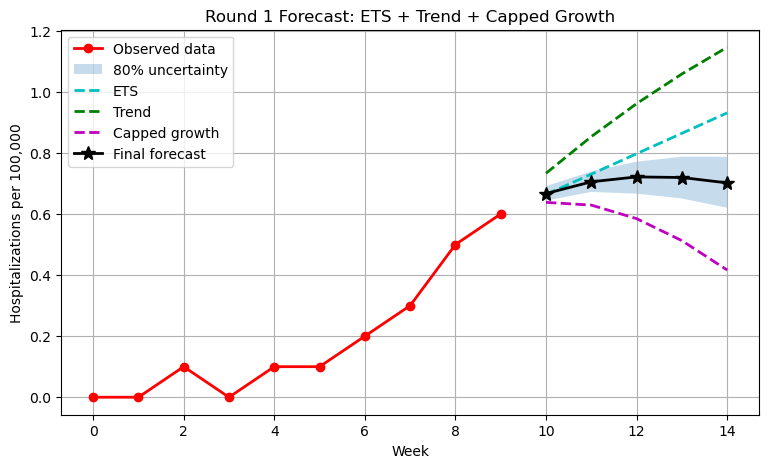


Round 1 capped-growth forecast files generated successfully.


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.holtwinters import ExponentialSmoothing

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\sample1.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 5
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# ETS FORECAST
# ============================================================

try:
    ets_model = ExponentialSmoothing(
        hosp,
        trend="add",
        seasonal=None,
        initialization_method="estimated",
    )
    ets_fit = ets_model.fit(optimized=True)
    ets_future = ets_fit.forecast(n_forecast)
except Exception as e:
    print("ETS failed:", e)
    ets_future = np.repeat(hosp[-1], n_forecast)

ets_future = np.maximum(ets_future, forecast_floor)

# ============================================================
# LOCAL TREND FORECAST
# ============================================================

recent = hosp[-4:] if len(hosp) >= 4 else hosp
slope = np.mean(np.diff(recent))

trend_future = []
current = hosp[-1]

for i in range(n_forecast):
    damping = 0.90 ** i
    current = max(current + damping * slope, forecast_floor)
    trend_future.append(current)

trend_future = np.array(trend_future)

# ============================================================
# CAPPED GROWTH BACKUP
# ============================================================

lag0 = hosp[-1]
lag1 = hosp[-2]
lag2 = hosp[-3]

v1 = lag0 - lag1
v0 = lag1 - lag2
acc = v1 - v0

cap_level = max(3.0, 2.5 * lag0)

direct_future = []
current = lag0
velocity = v1

for i in range(n_forecast):
    slowdown = max(0.20, 1 - current / cap_level)

    velocity = velocity + 0.5 * acc
    velocity = 0.95 * velocity * slowdown

    current = max(current + velocity, forecast_floor)
    direct_future.append(current)

direct_future = np.array(direct_future)

# ============================================================
# FINAL FORECAST
# ============================================================

final_forecast = (
    0.20 * ets_future
    + 0.25 * trend_future
    + 0.55 * direct_future
)

final_forecast = np.maximum(final_forecast, forecast_floor)

# ============================================================
# UNCERTAINTY ENSEMBLE
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ets_perturbation = 0.12
trend_perturbation = 0.15
direct_perturbation = 0.20

ensemble = np.zeros((n_forecast, n_ens))

for j in range(n_ens):
    ets_j = ets_future * (1 + ets_perturbation * rng.normal(size=n_forecast))
    ets_j = np.maximum(ets_j, forecast_floor)

    slope_j = slope * (1 + trend_perturbation * rng.normal())

    trend_j = []
    current_j = hosp[-1]

    for i in range(n_forecast):
        damping = 0.90 ** i
        current_j = max(current_j + damping * slope_j, forecast_floor)
        trend_j.append(current_j)

    trend_j = np.array(trend_j)

    v1_j = v1 * (1 + direct_perturbation * rng.normal())
    acc_j = acc * (1 + direct_perturbation * rng.normal())
    cap_j = cap_level * (1 + 0.10 * rng.normal())
    cap_j = max(cap_j, 2.0)

    direct_j = []
    current_j = lag0
    velocity_j = v1_j

    for i in range(n_forecast):
        slowdown_j = max(0.20, 1 - current_j / cap_j)

        velocity_j = velocity_j + 0.5 * acc_j
        velocity_j = 0.95 * velocity_j * slowdown_j

        current_j = max(current_j + velocity_j, forecast_floor)
        direct_j.append(current_j)

    direct_j = np.array(direct_j)

    ensemble[:, j] = (
        0.20 * ets_j
        + 0.25 * trend_j
        + 0.55 * direct_j
    )

ensemble = np.maximum(ensemble, forecast_floor)

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": np.concatenate([week, future_weeks]),
    "Hosp": np.concatenate([hosp, final_forecast]),
})

submission.to_csv("round1_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
})

uncertainty.to_csv("round1_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== ROUND 1 CAPPED-GROWTH FORECAST =====")
print(f"Recent velocity     = {v1:.4f}")
print(f"Recent acceleration = {acc:.4f}")
print(f"Cap level           = {cap_level:.4f}")

print("\n===== 5-WEEK FORECAST =====")
for w, h, lo, hi in zip(future_weeks, final_forecast, lower10, upper90):
    print(f"Week {int(w)}: Hosp={h:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS")
plt.plot(future_weeks, trend_future, "g--", linewidth=2, label="Trend")
plt.plot(future_weeks, direct_future, "m--", linewidth=2, label="Capped growth")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Final forecast")
plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Round 1 Forecast: ETS + Trend + Capped Growth")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Round1_capped_growth_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nRound 1 capped-growth forecast files generated successfully.")


===== ROUND 1 SURGE FORECAST =====
Surge ratios: [1.8  1.6  1.4  1.1  0.85]

===== 5-WEEK FORECAST =====
Week 10: Hosp=1.0037 [0.8905, 1.1086]
Week 11: Hosp=1.5408 [1.2981, 1.7625]
Week 12: Hosp=2.1112 [1.6940, 2.5503]
Week 13: Hosp=2.3212 [1.7938, 2.8290]
Week 14: Hosp=2.0173 [1.5098, 2.5262]


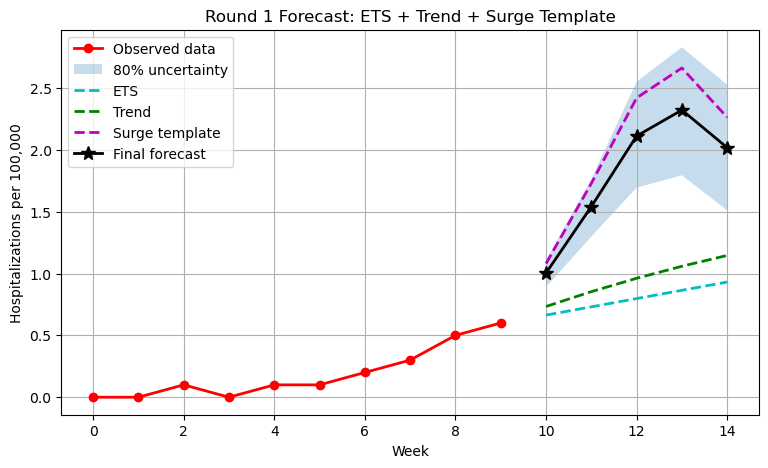


Round 1 surge-template forecast generated successfully.


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.holtwinters import ExponentialSmoothing

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\sample1.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 5
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# ETS FORECAST
# ============================================================

try:
    ets_model = ExponentialSmoothing(
        hosp,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )
    ets_fit = ets_model.fit(optimized=True)
    ets_future = ets_fit.forecast(n_forecast)

except Exception as e:
    print("ETS failed:", e)
    ets_future = np.repeat(hosp[-1], n_forecast)

ets_future = np.maximum(ets_future, forecast_floor)

# ============================================================
# TREND FORECAST
# ============================================================

recent = hosp[-4:] if len(hosp) >= 4 else hosp
slope = np.mean(np.diff(recent))

trend_future = []
current = hosp[-1]

for i in range(n_forecast):
    damping = 0.90 ** i
    current = max(current + damping * slope, forecast_floor)
    trend_future.append(current)

trend_future = np.array(trend_future)

# ============================================================
# SURGE TEMPLATE FORECAST
# ============================================================

current = hosp[-1]

surge_ratios = np.array([1.80, 1.60, 1.40, 1.10, 0.85])

surge_future = []

for r in surge_ratios:
    current = max(current * r, forecast_floor)
    surge_future.append(current)

surge_future = np.array(surge_future)

# ============================================================
# FINAL FORECAST
# ============================================================

final_forecast = (
    0.10 * ets_future
    + 0.10 * trend_future
    + 0.80 * surge_future
)

final_forecast = np.maximum(final_forecast, forecast_floor)

# ============================================================
# UNCERTAINTY
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))

ets_perturbation = 0.10
trend_perturbation = 0.15
surge_perturbation = 0.10

for j in range(n_ens):

    ets_j = ets_future * (1 + ets_perturbation * rng.normal(size=n_forecast))
    ets_j = np.maximum(ets_j, forecast_floor)

    slope_j = slope * (1 + trend_perturbation * rng.normal())

    trend_j = []
    current_j = hosp[-1]

    for i in range(n_forecast):
        damping = 0.90 ** i
        current_j = max(current_j + damping * slope_j, forecast_floor)
        trend_j.append(current_j)

    trend_j = np.array(trend_j)

    ratio_noise = surge_ratios * (1 + surge_perturbation * rng.normal(size=n_forecast))
    ratio_noise = np.clip(ratio_noise, 0.70, 2.20)

    surge_j = []
    current_j = hosp[-1]

    for r in ratio_noise:
        current_j = max(current_j * r, forecast_floor)
        surge_j.append(current_j)

    surge_j = np.array(surge_j)

    ensemble[:, j] = (
        0.10 * ets_j
        + 0.10 * trend_j
        + 0.80 * surge_j
    )

ensemble = np.maximum(ensemble, forecast_floor)

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": np.concatenate([week, future_weeks]),
    "Hosp": np.concatenate([hosp, final_forecast])
})

submission.to_csv("round1_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90
})

uncertainty.to_csv("round1_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== ROUND 1 SURGE FORECAST =====")
print("Surge ratios:", surge_ratios)

print("\n===== 5-WEEK FORECAST =====")
for w, h, lo, hi in zip(future_weeks, final_forecast, lower10, upper90):
    print(f"Week {int(w)}: Hosp={h:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS")
plt.plot(future_weeks, trend_future, "g--", linewidth=2, label="Trend")
plt.plot(future_weeks, surge_future, "m--", linewidth=2, label="Surge template")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Final forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Round 1 Forecast: ETS + Trend + Surge Template")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Round1_surge_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nRound 1 surge-template forecast generated successfully.")


===== ROUND 1 SURGE FORECAST =====
Surge ratios: [1.85 1.7  1.5  1.12 0.86]

===== 5-WEEK FORECAST =====
Week 10: Hosp=1.0500 [0.9286, 1.1644]
Week 11: Hosp=1.7258 [1.4503, 1.9818]
Week 12: Hosp=2.5419 [2.0276, 3.0940]
Week 13: Hosp=2.8437 [2.1773, 3.4855]
Week 14: Hosp=2.4785 [1.8309, 3.1346]


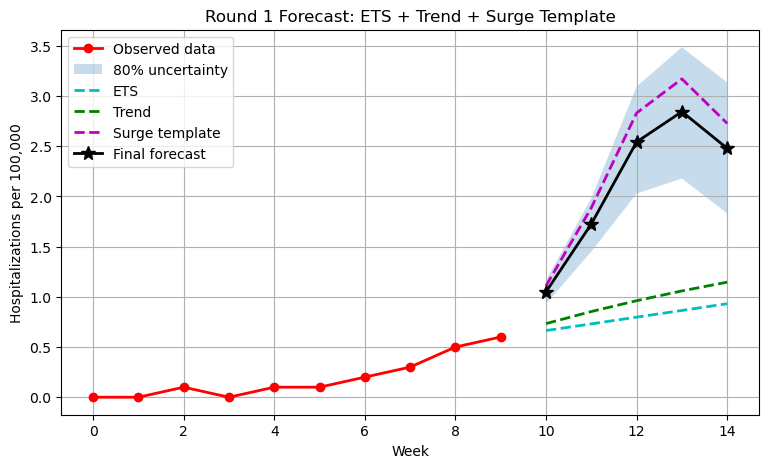


Round 1 surge-template forecast generated successfully.


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.holtwinters import ExponentialSmoothing

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\sample1.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 5
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# ETS FORECAST
# ============================================================

try:
    ets_model = ExponentialSmoothing(
        hosp,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )
    ets_fit = ets_model.fit(optimized=True)
    ets_future = ets_fit.forecast(n_forecast)

except Exception as e:
    print("ETS failed:", e)
    ets_future = np.repeat(hosp[-1], n_forecast)

ets_future = np.maximum(ets_future, forecast_floor)

# ============================================================
# TREND FORECAST
# ============================================================

recent = hosp[-4:] if len(hosp) >= 4 else hosp
slope = np.mean(np.diff(recent))

trend_future = []
current = hosp[-1]

for i in range(n_forecast):
    damping = 0.90 ** i
    current = max(current + damping * slope, forecast_floor)
    trend_future.append(current)

trend_future = np.array(trend_future)

# ============================================================
# SURGE TEMPLATE FORECAST
# ============================================================

current = hosp[-1]

surge_ratios = np.array([1.85, 1.70, 1.50, 1.12, 0.86])

surge_future = []

for r in surge_ratios:
    current = max(current * r, forecast_floor)
    surge_future.append(current)

surge_future = np.array(surge_future)

# ============================================================
# FINAL FORECAST
# ============================================================

final_forecast = (
    0.05 * ets_future
    + 0.10 * trend_future
    + 0.85 * surge_future
)

final_forecast = np.maximum(final_forecast, forecast_floor)

# ============================================================
# UNCERTAINTY
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))

ets_perturbation = 0.10
trend_perturbation = 0.15
surge_perturbation = 0.10

for j in range(n_ens):

    ets_j = ets_future * (1 + ets_perturbation * rng.normal(size=n_forecast))
    ets_j = np.maximum(ets_j, forecast_floor)

    slope_j = slope * (1 + trend_perturbation * rng.normal())

    trend_j = []
    current_j = hosp[-1]

    for i in range(n_forecast):
        damping = 0.90 ** i
        current_j = max(current_j + damping * slope_j, forecast_floor)
        trend_j.append(current_j)

    trend_j = np.array(trend_j)

    ratio_noise = surge_ratios * (1 + surge_perturbation * rng.normal(size=n_forecast))
    ratio_noise = np.clip(ratio_noise, 0.70, 2.20)

    surge_j = []
    current_j = hosp[-1]

    for r in ratio_noise:
        current_j = max(current_j * r, forecast_floor)
        surge_j.append(current_j)

    surge_j = np.array(surge_j)

    ensemble[:, j] = (
        0.05 * ets_j
        + 0.10 * trend_j
        + 0.85 * surge_j
    )

ensemble = np.maximum(ensemble, forecast_floor)

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": np.concatenate([week, future_weeks]),
    "Hosp": np.concatenate([hosp, final_forecast])
})

submission.to_csv("round1_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90
})

uncertainty.to_csv("round1_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== ROUND 1 SURGE FORECAST =====")
print("Surge ratios:", surge_ratios)

print("\n===== 5-WEEK FORECAST =====")
for w, h, lo, hi in zip(future_weeks, final_forecast, lower10, upper90):
    print(f"Week {int(w)}: Hosp={h:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS")
plt.plot(future_weeks, trend_future, "g--", linewidth=2, label="Trend")
plt.plot(future_weeks, surge_future, "m--", linewidth=2, label="Surge template")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Final forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Round 1 Forecast: ETS + Trend + Surge Template")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Round1_surge_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nRound 1 surge-template forecast generated successfully.")


===== CHALLENGE 2 RELEASE 1 FORECAST =====
Shock ratios: [2.2 5.  3.3 1.5]

===== 4-WEEK FORECAST =====
Week 9: Hosp=1.0347 [0.8770, 1.1838]
Week 10: Hosp=4.9952 [3.9070, 6.1480]
Week 11: Hosp=16.3807 [12.3396, 20.9476]
Week 12: Hosp=24.5487 [17.7726, 32.6612]


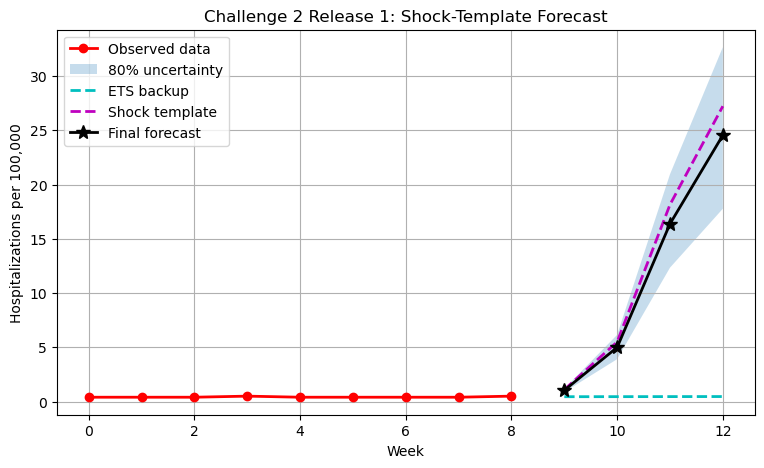


Challenge 2 release 1 forecast files generated successfully.


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.holtwinters import ExponentialSmoothing

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data1.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# ETS BACKUP
# ============================================================

try:
    ets_model = ExponentialSmoothing(
        hosp,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )
    ets_fit = ets_model.fit(optimized=True)
    ets_future = ets_fit.forecast(n_forecast)

except Exception as e:
    print("ETS failed:", e)
    ets_future = np.repeat(hosp[-1], n_forecast)

ets_future = np.maximum(ets_future, forecast_floor)

# ============================================================
# SHOCK / SECOND-AGENT SURGE TEMPLATE
# ============================================================

current = hosp[-1]

shock_ratios = np.array([2.2, 5.0, 3.3, 1.5])

shock_future = []

for r in shock_ratios:
    current = max(current * r, forecast_floor)
    shock_future.append(current)

shock_future = np.array(shock_future)

# ============================================================
# FINAL FORECAST
# ============================================================

final_forecast = 0.90 * shock_future + 0.10 * ets_future
final_forecast = np.maximum(final_forecast, forecast_floor)

# ============================================================
# UNCERTAINTY
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))

shock_perturbation = 0.12
ets_perturbation = 0.05

for j in range(n_ens):

    ratio_j = shock_ratios * (1 + shock_perturbation * rng.normal(size=n_forecast))
    ratio_j = np.clip(ratio_j, 0.75, 6.0)

    shock_j = []
    current_j = hosp[-1]

    for r in ratio_j:
        current_j = max(current_j * r, forecast_floor)
        shock_j.append(current_j)

    shock_j = np.array(shock_j)

    ets_j = ets_future * (1 + ets_perturbation * rng.normal(size=n_forecast))
    ets_j = np.maximum(ets_j, forecast_floor)

    ensemble[:, j] = 0.90 * shock_j + 0.10 * ets_j

ensemble = np.maximum(ensemble, forecast_floor)

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": np.concatenate([week, future_weeks]),
    "Hosp": np.concatenate([hosp, final_forecast])
})

submission.to_csv("challenge2_release1_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90
})

uncertainty.to_csv("challenge2_release1_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 RELEASE 1 FORECAST =====")
print("Shock ratios:", shock_ratios)

print("\n===== 4-WEEK FORECAST =====")
for w, h, lo, hi in zip(future_weeks, final_forecast, lower10, upper90):
    print(f"Week {int(w)}: Hosp={h:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS backup")
plt.plot(future_weeks, shock_future, "m--", linewidth=2, label="Shock template")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Final forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Release 1: Shock-Template Forecast")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_release1_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 release 1 forecast files generated successfully.")


===== CHALLENGE 2 RELEASE 1 FORECAST =====
Shock ratios: [2.2   5.    3.29  1.492]

===== 4-WEEK FORECAST =====
Week 9: Hosp=1.1000 [0.8770, 1.1838]
Week 10: Hosp=5.5000 [3.9070, 6.1480]
Week 11: Hosp=18.0950 [12.3024, 20.8843]
Week 12: Hosp=26.9977 [17.6246, 32.3889]


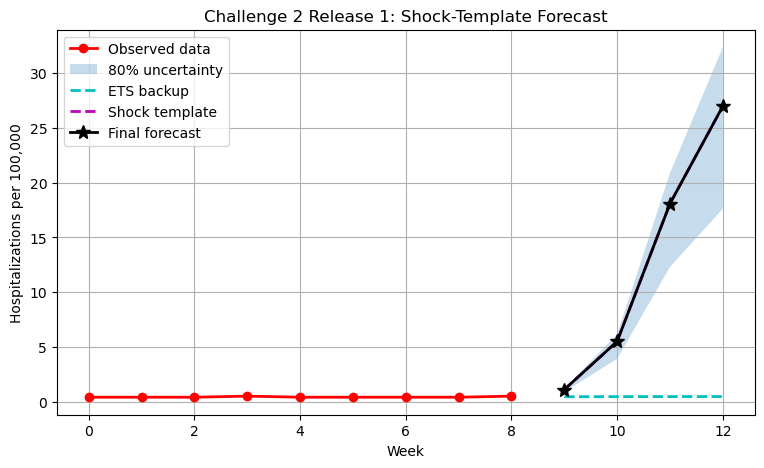


Challenge 2 release 1 forecast files generated successfully.


ValueError: x and y must have same first dimension, but have shapes (4,) and (5,)

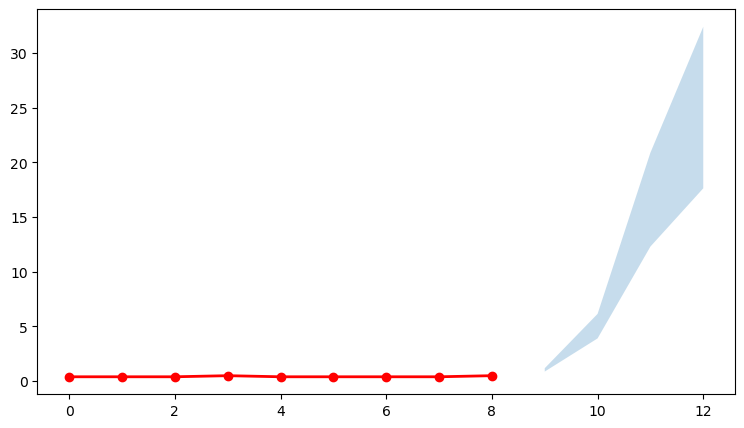

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.holtwinters import ExponentialSmoothing

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data1.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# ETS BACKUP
# ============================================================

try:
    ets_model = ExponentialSmoothing(
        hosp,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )
    ets_fit = ets_model.fit(optimized=True)
    ets_future = ets_fit.forecast(n_forecast)

except Exception as e:
    print("ETS failed:", e)
    ets_future = np.repeat(hosp[-1], n_forecast)

ets_future = np.maximum(ets_future, forecast_floor)

# ============================================================
# SHOCK / SECOND-AGENT SURGE TEMPLATE
# ============================================================

current = hosp[-1]

shock_ratios = np.array([2.2, 5.0, 3.29, 1.492])

shock_future = []

for r in shock_ratios:
    current = max(current * r, forecast_floor)
    shock_future.append(current)

shock_future = np.array(shock_future)

# ============================================================
# FINAL FORECAST
# ============================================================

final_forecast = 1 * shock_future + 0 * ets_future
final_forecast = np.maximum(final_forecast, forecast_floor)

# ============================================================
# UNCERTAINTY
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))

shock_perturbation = 0.12
ets_perturbation = 0.05

for j in range(n_ens):

    ratio_j = shock_ratios * (1 + shock_perturbation * rng.normal(size=n_forecast))
    ratio_j = np.clip(ratio_j, 0.75, 6.0)

    shock_j = []
    current_j = hosp[-1]

    for r in ratio_j:
        current_j = max(current_j * r, forecast_floor)
        shock_j.append(current_j)

    shock_j = np.array(shock_j)

    ets_j = ets_future * (1 + ets_perturbation * rng.normal(size=n_forecast))
    ets_j = np.maximum(ets_j, forecast_floor)

    ensemble[:, j] = 0.90 * shock_j + 0.10 * ets_j

ensemble = np.maximum(ensemble, forecast_floor)

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": np.concatenate([week, future_weeks]),
    "Hosp": np.concatenate([hosp, final_forecast])
})

submission.to_csv("challenge2_release1_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90
})

uncertainty.to_csv("challenge2_release1_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 RELEASE 1 FORECAST =====")
print("Shock ratios:", shock_ratios)

print("\n===== 4-WEEK FORECAST =====")
for w, h, lo, hi in zip(future_weeks, final_forecast, lower10, upper90):
    print(f"Week {int(w)}: Hosp={h:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS backup")
plt.plot(future_weeks, shock_future, "m--", linewidth=2, label="Shock template")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Final forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Release 1: Shock-Template Forecast")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_release1_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 release 1 forecast files generated successfully.")

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, hybrid_future, "k*-", linewidth=2, markersize=10, label="Hybrid forecast")
plt.plot(future_weeks, exp_future, "m--", linewidth=2, label="Exponential backup")
plt.plot(future_weeks, trend_future, "g--", linewidth=2, label="Trend")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS")
plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Round 1 Forecast: Early-Growth Model")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Round1_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# REPORT FIGURES
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Figure 1: Observed Hospitalization Data")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Figure1_observed_data.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.plot(all_weeks, sirh_full, "b-", linewidth=2, label="SIR-H model")
plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Figure 2: SIR-H Model Fit and Forecast")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Figure2_sirh_fit.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty band")
plt.plot(future_weeks, hybrid_future, "k*-", linewidth=2, markersize=10, label="Hybrid forecast")
plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Figure 3: Five-Week Hybrid Forecast with Uncertainty")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Figure3_hybrid_forecast_uncertainty.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(all_weeks, Rt_full, "m-", linewidth=2, label="Rt from fitted SIR-H")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")
plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Figure 4: Estimated Effective Reproduction Number Rt")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Figure4_Rt_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.plot(all_weeks, sirh_full, "b-", linewidth=2, label="SIR-H")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS")
plt.plot(future_weeks, trend_future, "g--", linewidth=2, label="Trend")
plt.plot(future_weeks, hybrid_future, "k*-", linewidth=2, markersize=10, label="Hybrid forecast")
plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Figure 5: Forecast Component Comparison")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Figure5_component_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nAll files and report figures generated successfully.")


print("\nRound 1 forecast files generated successfully.")


===== CHALLENGE 2 RELEASE 1 SHOCK FORECAST =====
Shock ratios: [2.2   4.    3.29  1.492]

===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====
Week 13: Hosp=59.4000, Rt=2.2000 HospInterval=[53.8116, 65.4087] RtInterval=[1.9930, 2.4225]
Week 14: Hosp=237.6000, Rt=4.0000 HospInterval=[203.3258, 272.1513] RtInterval=[3.5859, 4.4159]
Week 15: Hosp=781.7040, Rt=3.2900 HospInterval=[649.1309, 921.8049] RtInterval=[2.9329, 3.6147]
Week 16: Hosp=1166.3024, Rt=1.4920 HospInterval=[942.9332, 1403.2275] RtInterval=[1.3364, 1.6431]


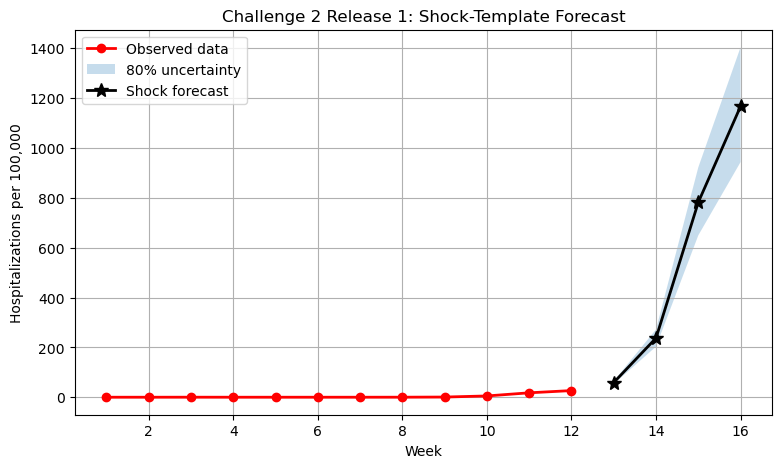

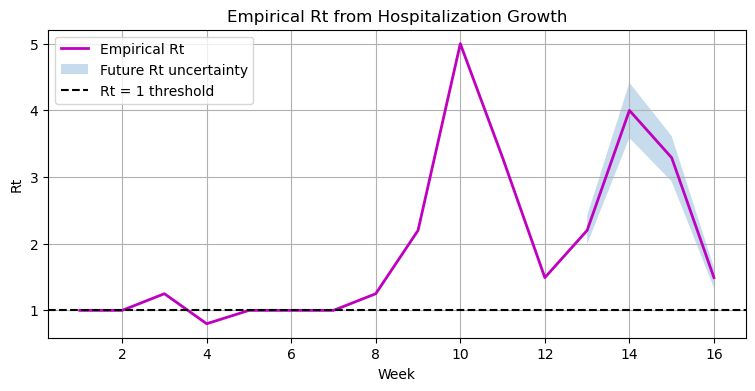


Challenge 2 release 1 forecast, uncertainty, and Rt files generated successfully.


In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.holtwinters import ExponentialSmoothing

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data2.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# ETS BACKUP
# ============================================================

try:
    ets_model = ExponentialSmoothing(
        hosp,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )
    ets_fit = ets_model.fit(optimized=True)
    ets_future = ets_fit.forecast(n_forecast)

except Exception as e:
    print("ETS failed:", e)
    ets_future = np.repeat(hosp[-1], n_forecast)

ets_future = np.maximum(ets_future, forecast_floor)

# ============================================================
# SHOCK TEMPLATE FORECAST
# ============================================================

current = hosp[-1]

shock_ratios = np.array([2.2, 4.0, 3.29, 1.492])

shock_future = []

for r in shock_ratios:
    current = max(current * r, forecast_floor)
    shock_future.append(current)

shock_future = np.array(shock_future)

# ============================================================
# FINAL FORECAST
# ============================================================

final_forecast = shock_future.copy()
final_forecast = np.maximum(final_forecast, forecast_floor)

# ============================================================
# EMPIRICAL Rt FROM HOSPITALIZATION GROWTH
# ============================================================

generation_time = 1.0

all_weeks = np.concatenate([week, future_weeks])
all_hosp = np.concatenate([hosp, final_forecast])

Rt_empirical = np.ones_like(all_hosp)

for i in range(1, len(all_hosp)):
    if all_hosp[i - 1] > 0:
        Rt_empirical[i] = (all_hosp[i] / all_hosp[i - 1]) ** generation_time
    else:
        Rt_empirical[i] = np.nan

Rt_future = Rt_empirical[-n_forecast:]

# ============================================================
# UNCERTAINTY
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))
Rt_ens = np.zeros((n_forecast, n_ens))

shock_perturbation = 0.08

for j in range(n_ens):

    ratio_j = shock_ratios * (1 + shock_perturbation * rng.normal(size=n_forecast))
    ratio_j = np.clip(ratio_j, 0.70, 6.00)

    shock_j = []
    current_j = hosp[-1]

    for r in ratio_j:
        current_j = max(current_j * r, forecast_floor)
        shock_j.append(current_j)

    shock_j = np.array(shock_j)

    ensemble[:, j] = shock_j

    all_hosp_j = np.concatenate([hosp, shock_j])

    Rt_j = np.ones_like(all_hosp_j)

    for i in range(1, len(all_hosp_j)):
        if all_hosp_j[i - 1] > 0:
            Rt_j[i] = (all_hosp_j[i] / all_hosp_j[i - 1]) ** generation_time
        else:
            Rt_j[i] = np.nan

    Rt_ens[:, j] = Rt_j[-n_forecast:]

ensemble = np.maximum(ensemble, forecast_floor)

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

Rt_lower10 = np.percentile(Rt_ens, 10, axis=1)
Rt_median50 = np.percentile(Rt_ens, 50, axis=1)
Rt_upper90 = np.percentile(Rt_ens, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": all_weeks,
    "Hosp": all_hosp,
    "Rt": Rt_empirical
})

submission.to_csv("challenge2_release1_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
    "Rt_Lower10": Rt_lower10,
    "Rt_Median": Rt_median50,
    "Rt_Upper90": Rt_upper90
})

uncertainty.to_csv("challenge2_release1_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 RELEASE 1 SHOCK FORECAST =====")
print("Shock ratios:", shock_ratios)

print("\n===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====")
for w, h, rt, lo, hi, rtl, rtu in zip(
    future_weeks,
    final_forecast,
    Rt_future,
    lower10,
    upper90,
    Rt_lower10,
    Rt_upper90
):
    print(
        f"Week {int(w)}: "
        f"Hosp={h:.4f}, "
        f"Rt={rt:.4f} "
        f"HospInterval=[{lo:.4f}, {hi:.4f}] "
        f"RtInterval=[{rtl:.4f}, {rtu:.4f}]"
    )

# ============================================================
# PLOT 1: FORECAST
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Shock forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Release 1: Shock-Template Forecast")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_release1_forecast.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# PLOT 2: Rt
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(all_weeks, Rt_empirical, "m-", linewidth=2, label="Empirical Rt")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")

plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Empirical Rt from Hospitalization Growth")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_release1_Rt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 release 1 forecast, uncertainty, and Rt files generated successfully.")


===== CHALLENGE 2 ROUND 2 FORECAST =====

===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====
Week 13: Hosp=29.9408, Rt=1.1089 [26.8662, 31.0400]
Week 14: Hosp=30.2608, Rt=1.0107 [25.8689, 31.0825]
Week 15: Hosp=28.8767, Rt=0.9543 [23.5099, 29.2364]
Week 16: Hosp=27.1390, Rt=0.9398 [20.7752, 26.5514]


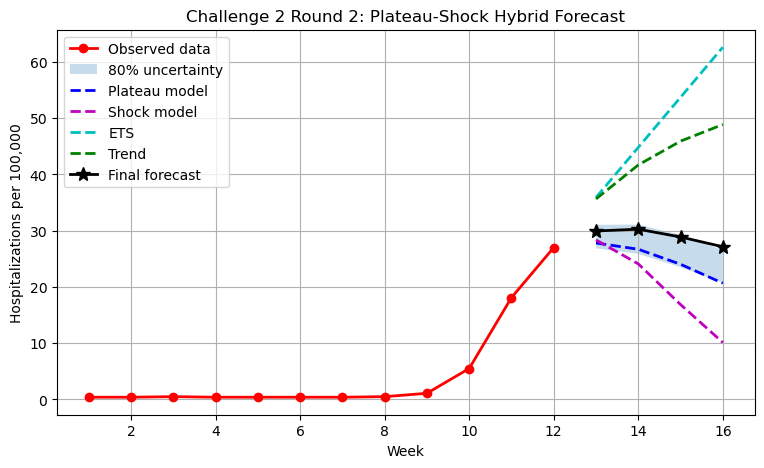

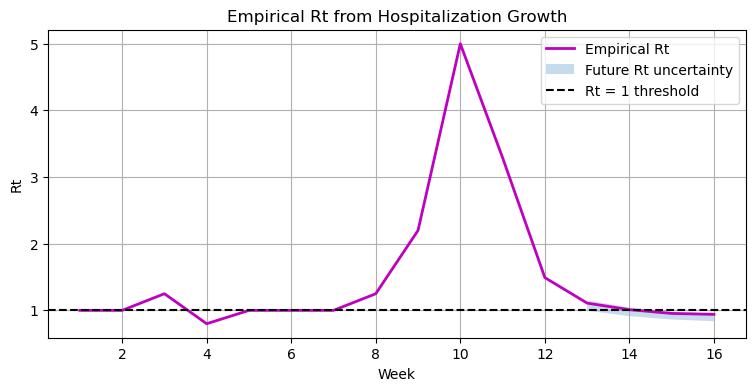


Challenge 2 Round 2 forecast generated successfully.


In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.holtwinters import ExponentialSmoothing

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data2.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# ETS FORECAST
# ============================================================

try:
    ets_model = ExponentialSmoothing(
        hosp,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )
    ets_fit = ets_model.fit(optimized=True)
    ets_future = ets_fit.forecast(n_forecast)
except Exception as e:
    print("ETS failed:", e)
    ets_future = np.repeat(hosp[-1], n_forecast)

ets_future = np.maximum(ets_future, forecast_floor)

# ============================================================
# LOCAL TREND FORECAST
# ============================================================

recent = hosp[-4:]
slope = np.mean(np.diff(recent))

trend_future = []
current = hosp[-1]

for i in range(n_forecast):
    damping = 0.70 ** i
    current = max(current + damping * slope, forecast_floor)
    trend_future.append(current)

trend_future = np.array(trend_future)

# ============================================================
# SHOCK CONTINUATION MODEL
# ============================================================

current = hosp[-1]

shock_ratios = np.array([1.05, 0.85, 0.70, 0.60])

shock_future = []

for r in shock_ratios:
    current = max(current * r, forecast_floor)
    shock_future.append(current)

shock_future = np.array(shock_future)

# ============================================================
# PLATEAU / SLOW-DECLINE MODEL
# ============================================================

current = hosp[-1]

plateau_ratios = np.array([1.03, 0.96, 0.90, 0.86])

plateau_future = []

for r in plateau_ratios:
    current = max(current * r, forecast_floor)
    plateau_future.append(current)

plateau_future = np.array(plateau_future)

# ============================================================
# FINAL FORECAST
# ============================================================

final_forecast = (
    0.50 * plateau_future
    + 0.25 * shock_future
    + 0.15 * ets_future
    + 0.10 * trend_future
)

final_forecast = np.maximum(final_forecast, forecast_floor)

# ============================================================
# EMPIRICAL Rt
# ============================================================

all_weeks = np.concatenate([week, future_weeks])
all_hosp = np.concatenate([hosp, final_forecast])

Rt_empirical = np.ones_like(all_hosp)

for i in range(1, len(all_hosp)):
    if all_hosp[i - 1] > 0:
        Rt_empirical[i] = all_hosp[i] / all_hosp[i - 1]
    else:
        Rt_empirical[i] = np.nan

Rt_future = Rt_empirical[-n_forecast:]

# ============================================================
# UNCERTAINTY ENSEMBLE
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))
Rt_ens = np.zeros((n_forecast, n_ens))

for j in range(n_ens):

    ets_j = ets_future * (1 + 0.08 * rng.normal(size=n_forecast))
    ets_j = np.maximum(ets_j, forecast_floor)

    slope_j = slope * (1 + 0.12 * rng.normal())

    trend_j = []
    current_j = hosp[-1]

    for i in range(n_forecast):
        damping = 0.70 ** i
        current_j = max(current_j + damping * slope_j, forecast_floor)
        trend_j.append(current_j)

    trend_j = np.array(trend_j)

    shock_ratio_j = shock_ratios * (1 + 0.10 * rng.normal(size=n_forecast))
    shock_ratio_j = np.clip(shock_ratio_j, 0.40, 1.30)

    shock_j = []
    current_j = hosp[-1]

    for r in shock_ratio_j:
        current_j = max(current_j * r, forecast_floor)
        shock_j.append(current_j)

    shock_j = np.array(shock_j)

    plateau_ratio_j = plateau_ratios * (1 + 0.08 * rng.normal(size=n_forecast))
    plateau_ratio_j = np.clip(plateau_ratio_j, 0.70, 1.20)

    plateau_j = []
    current_j = hosp[-1]

    for r in plateau_ratio_j:
        current_j = max(current_j * r, forecast_floor)
        plateau_j.append(current_j)

    plateau_j = np.array(plateau_j)

    forecast_j = (
        0.60 * plateau_j
        + 0.25 * shock_j
        + 0.10 * ets_j
        + 0.05 * trend_j
    )

    ensemble[:, j] = np.maximum(forecast_j, forecast_floor)

    all_hosp_j = np.concatenate([hosp, ensemble[:, j]])

    Rt_j = np.ones_like(all_hosp_j)

    for i in range(1, len(all_hosp_j)):
        Rt_j[i] = all_hosp_j[i] / all_hosp_j[i - 1]

    Rt_ens[:, j] = Rt_j[-n_forecast:]

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

Rt_lower10 = np.percentile(Rt_ens, 10, axis=1)
Rt_median50 = np.percentile(Rt_ens, 50, axis=1)
Rt_upper90 = np.percentile(Rt_ens, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": all_weeks,
    "Hosp": all_hosp,
    "Rt": Rt_empirical
})

submission.to_csv("challenge2_round2_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
    "Rt_Lower10": Rt_lower10,
    "Rt_Median": Rt_median50,
    "Rt_Upper90": Rt_upper90
})

uncertainty.to_csv("challenge2_round2_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 ROUND 2 FORECAST =====")

print("\n===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====")
for w, h, rt, lo, hi in zip(future_weeks, final_forecast, Rt_future, lower10, upper90):
    print(f"Week {int(w)}: Hosp={h:.4f}, Rt={rt:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT FORECAST
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, plateau_future, "b--", linewidth=2, label="Plateau model")
plt.plot(future_weeks, shock_future, "m--", linewidth=2, label="Shock model")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS")
plt.plot(future_weeks, trend_future, "g--", linewidth=2, label="Trend")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Final forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Round 2: Plateau-Shock Hybrid Forecast")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Challenge2_round2_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT Rt
# ============================================================

plt.figure(figsize=(9, 4))
plt.plot(all_weeks, Rt_empirical, "m-", linewidth=2, label="Empirical Rt")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")

plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Empirical Rt from Hospitalization Growth")
plt.legend()
plt.grid(True)
plt.savefig("report_figures/Challenge2_round2_Rt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 Round 2 forecast generated successfully.")


===== CHALLENGE 2 ROUND 3: CRASH-REBOUND FORECAST =====

===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====
Week 13: Hosp=32.0608, Rt=1.1874 [29.6393, 34.3515]
Week 14: Hosp=36.4840, Rt=1.1380 [32.6379, 40.5445]
Week 15: Hosp=40.0549, Rt=1.0979 [34.9147, 45.3885]
Week 16: Hosp=42.4362, Rt=1.0595 [36.3826, 48.9664]


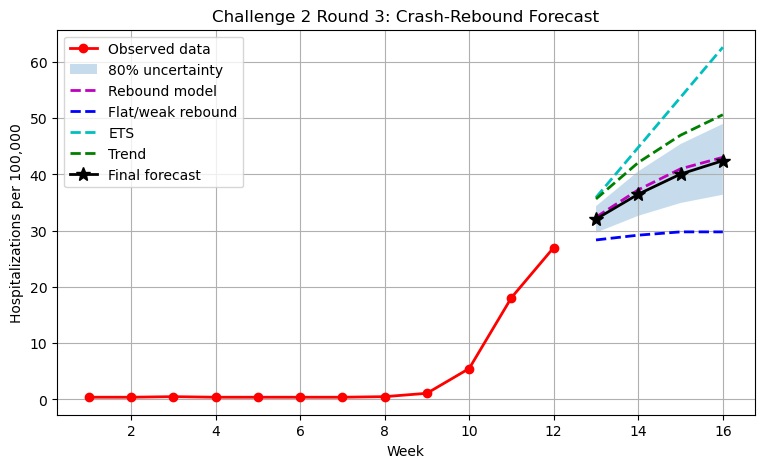

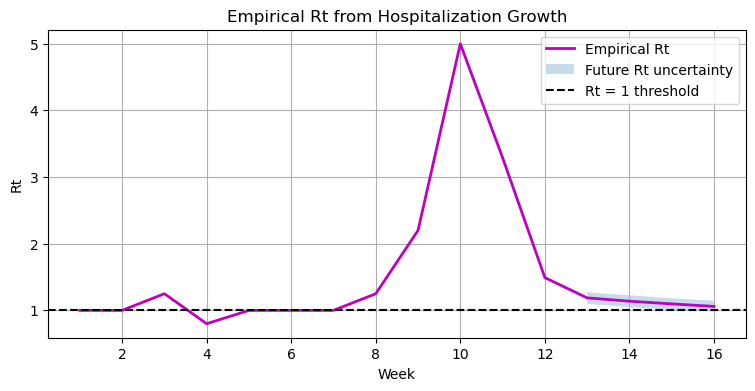


Challenge 2 Round 3 forecast generated successfully.


In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.holtwinters import ExponentialSmoothing

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data2.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# ETS FORECAST
# ============================================================

try:
    ets_model = ExponentialSmoothing(
        hosp,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )
    ets_fit = ets_model.fit(optimized=True)
    ets_future = ets_fit.forecast(n_forecast)
except Exception as e:
    print("ETS failed:", e)
    ets_future = np.repeat(hosp[-1], n_forecast)

ets_future = np.maximum(ets_future, forecast_floor)

# ============================================================
# LOCAL TREND FORECAST
# ============================================================

recent = hosp[-4:]
slope = np.mean(np.diff(recent))

trend_future = []
current = hosp[-1]

for i in range(n_forecast):
    damping = 0.75 ** i
    current = max(current + damping * slope, forecast_floor)
    trend_future.append(current)

trend_future = np.array(trend_future)

# ============================================================
# REBOUND TEMPLATE MODEL
# ============================================================

current = hosp[-1]

rebound_ratios = np.array([1.20, 1.15, 1.10, 1.05])

rebound_future = []

for r in rebound_ratios:
    current = max(current * r, forecast_floor)
    rebound_future.append(current)

rebound_future = np.array(rebound_future)

# ============================================================
# CONSERVATIVE FLAT/WEAK REBOUND MODEL
# ============================================================

current = hosp[-1]

flat_ratios = np.array([1.05, 1.03, 1.02, 1.00])

flat_future = []

for r in flat_ratios:
    current = max(current * r, forecast_floor)
    flat_future.append(current)

flat_future = np.array(flat_future)

# ============================================================
# FINAL FORECAST
# ============================================================

final_forecast = (
    0.55 * rebound_future
    + 0.25 * flat_future
    + 0.10 * ets_future
    + 0.10 * trend_future
)

final_forecast = np.maximum(final_forecast, forecast_floor)

# ============================================================
# EMPIRICAL Rt
# ============================================================

all_weeks = np.concatenate([week, future_weeks])
all_hosp = np.concatenate([hosp, final_forecast])

Rt_empirical = np.ones_like(all_hosp)

for i in range(1, len(all_hosp)):
    if all_hosp[i - 1] > 0:
        Rt_empirical[i] = all_hosp[i] / all_hosp[i - 1]
    else:
        Rt_empirical[i] = np.nan

Rt_future = Rt_empirical[-n_forecast:]

# ============================================================
# UNCERTAINTY ENSEMBLE
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))
Rt_ens = np.zeros((n_forecast, n_ens))

for j in range(n_ens):

    ets_j = ets_future * (1 + 0.08 * rng.normal(size=n_forecast))
    ets_j = np.maximum(ets_j, forecast_floor)

    slope_j = slope * (1 + 0.12 * rng.normal())

    trend_j = []
    current_j = hosp[-1]

    for i in range(n_forecast):
        damping = 0.75 ** i
        current_j = max(current_j + damping * slope_j, forecast_floor)
        trend_j.append(current_j)

    trend_j = np.array(trend_j)

    rebound_ratio_j = rebound_ratios * (1 + 0.10 * rng.normal(size=n_forecast))
    rebound_ratio_j = np.clip(rebound_ratio_j, 0.80, 1.50)

    rebound_j = []
    current_j = hosp[-1]

    for r in rebound_ratio_j:
        current_j = max(current_j * r, forecast_floor)
        rebound_j.append(current_j)

    rebound_j = np.array(rebound_j)

    flat_ratio_j = flat_ratios * (1 + 0.06 * rng.normal(size=n_forecast))
    flat_ratio_j = np.clip(flat_ratio_j, 0.80, 1.25)

    flat_j = []
    current_j = hosp[-1]

    for r in flat_ratio_j:
        current_j = max(current_j * r, forecast_floor)
        flat_j.append(current_j)

    flat_j = np.array(flat_j)

    forecast_j = (
        0.55 * rebound_j
        + 0.25 * flat_j
        + 0.10 * ets_j
        + 0.10 * trend_j
    )

    ensemble[:, j] = np.maximum(forecast_j, forecast_floor)

    all_hosp_j = np.concatenate([hosp, ensemble[:, j]])

    Rt_j = np.ones_like(all_hosp_j)

    for i in range(1, len(all_hosp_j)):
        Rt_j[i] = all_hosp_j[i] / all_hosp_j[i - 1]

    Rt_ens[:, j] = Rt_j[-n_forecast:]

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

Rt_lower10 = np.percentile(Rt_ens, 10, axis=1)
Rt_median50 = np.percentile(Rt_ens, 50, axis=1)
Rt_upper90 = np.percentile(Rt_ens, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": all_weeks,
    "Hosp": all_hosp,
    "Rt": Rt_empirical
})

submission.to_csv("challenge2_round3_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
    "Rt_Lower10": Rt_lower10,
    "Rt_Median": Rt_median50,
    "Rt_Upper90": Rt_upper90
})

uncertainty.to_csv("challenge2_round3_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 ROUND 3: CRASH-REBOUND FORECAST =====")

print("\n===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====")
for w, h, rt, lo, hi in zip(future_weeks, final_forecast, Rt_future, lower10, upper90):
    print(f"Week {int(w)}: Hosp={h:.4f}, Rt={rt:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT FORECAST
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, rebound_future, "m--", linewidth=2, label="Rebound model")
plt.plot(future_weeks, flat_future, "b--", linewidth=2, label="Flat/weak rebound")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS")
plt.plot(future_weeks, trend_future, "g--", linewidth=2, label="Trend")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Final forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Round 3: Crash-Rebound Forecast")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT Rt
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(all_weeks, Rt_empirical, "m-", linewidth=2, label="Empirical Rt")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")

plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Empirical Rt from Hospitalization Growth")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_Rt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 Round 3 forecast generated successfully.")


===== CHALLENGE 2 ROUND 3: CRASH-REBOUND FORECAST =====

===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====
Week 13: Hosp=32.0608, Rt=1.1874 [29.6393, 34.3515]
Week 14: Hosp=36.4840, Rt=1.1380 [32.6379, 40.5445]
Week 15: Hosp=40.0549, Rt=1.0979 [34.9147, 45.3885]
Week 16: Hosp=42.4362, Rt=1.0595 [36.3826, 48.9664]


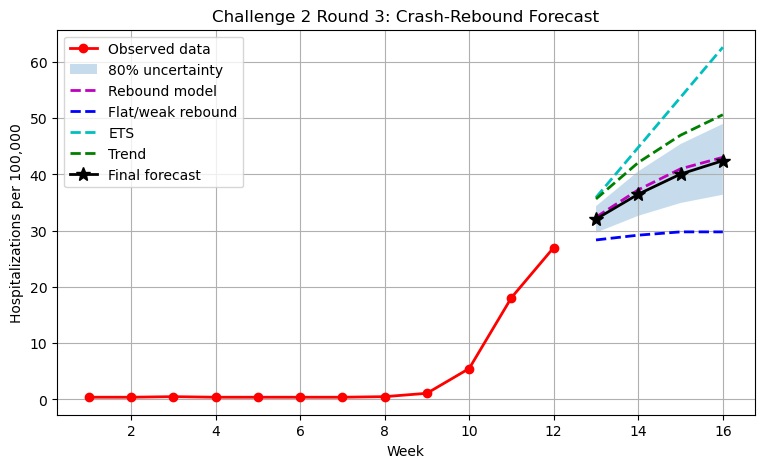

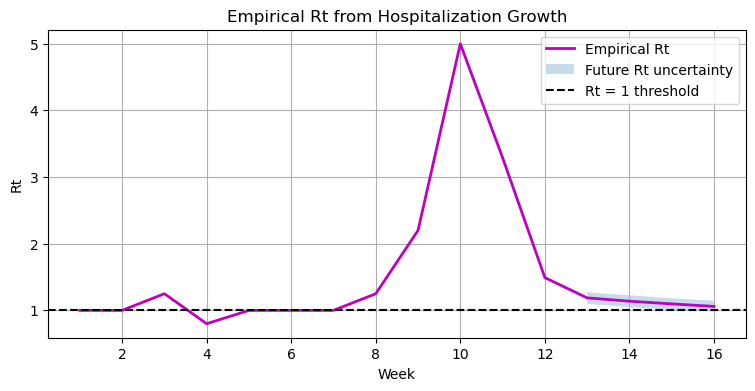


Challenge 2 Round 3 forecast generated successfully.


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from statsmodels.tsa.holtwinters import ExponentialSmoothing

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data2.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# ETS FORECAST
# ============================================================

try:
    ets_model = ExponentialSmoothing(
        hosp,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )
    ets_fit = ets_model.fit(optimized=True)
    ets_future = ets_fit.forecast(n_forecast)
except Exception as e:
    print("ETS failed:", e)
    ets_future = np.repeat(hosp[-1], n_forecast)

ets_future = np.maximum(ets_future, forecast_floor)

# ============================================================
# LOCAL TREND FORECAST
# ============================================================

recent = hosp[-4:]
slope = np.mean(np.diff(recent))

trend_future = []
current = hosp[-1]

for i in range(n_forecast):
    damping = 0.75 ** i
    current = max(current + damping * slope, forecast_floor)
    trend_future.append(current)

trend_future = np.array(trend_future)

# ============================================================
# REBOUND TEMPLATE MODEL
# ============================================================

current = hosp[-1]

rebound_ratios = np.array([1.20, 1.15, 1.10, 1.05])

rebound_future = []

for r in rebound_ratios:
    current = max(current * r, forecast_floor)
    rebound_future.append(current)

rebound_future = np.array(rebound_future)

# ============================================================
# CONSERVATIVE FLAT/WEAK REBOUND MODEL
# ============================================================

current = hosp[-1]

flat_ratios = np.array([1.05, 1.03, 1.02, 1.00])

flat_future = []

for r in flat_ratios:
    current = max(current * r, forecast_floor)
    flat_future.append(current)

flat_future = np.array(flat_future)

# ============================================================
# FINAL FORECAST
# ============================================================



# ============================================================
# EMPIRICAL Rt
# ============================================================

all_weeks = np.concatenate([week, future_weeks])
all_hosp = np.concatenate([hosp, final_forecast])

Rt_empirical = np.ones_like(all_hosp)

for i in range(1, len(all_hosp)):
    if all_hosp[i - 1] > 0:
        Rt_empirical[i] = all_hosp[i] / all_hosp[i - 1]
    else:
        Rt_empirical[i] = np.nan

Rt_future = Rt_empirical[-n_forecast:]

# ============================================================
# UNCERTAINTY ENSEMBLE
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))
Rt_ens = np.zeros((n_forecast, n_ens))

for j in range(n_ens):

    ets_j = ets_future * (1 + 0.08 * rng.normal(size=n_forecast))
    ets_j = np.maximum(ets_j, forecast_floor)

    slope_j = slope * (1 + 0.12 * rng.normal())

    trend_j = []
    current_j = hosp[-1]

    for i in range(n_forecast):
        damping = 0.75 ** i
        current_j = max(current_j + damping * slope_j, forecast_floor)
        trend_j.append(current_j)

    trend_j = np.array(trend_j)

    rebound_ratio_j = rebound_ratios * (1 + 0.10 * rng.normal(size=n_forecast))
    rebound_ratio_j = np.clip(rebound_ratio_j, 0.80, 1.50)

    rebound_j = []
    current_j = hosp[-1]

    for r in rebound_ratio_j:
        current_j = max(current_j * r, forecast_floor)
        rebound_j.append(current_j)

    rebound_j = np.array(rebound_j)

    flat_ratio_j = flat_ratios * (1 + 0.06 * rng.normal(size=n_forecast))
    flat_ratio_j = np.clip(flat_ratio_j, 0.80, 1.25)

    flat_j = []
    current_j = hosp[-1]

    for r in flat_ratio_j:
        current_j = max(current_j * r, forecast_floor)
        flat_j.append(current_j)

    flat_j = np.array(flat_j)

    forecast_j = (
        0.55 * rebound_j
        + 0.25 * flat_j
        + 0.10 * ets_j
        + 0.10 * trend_j
    )

    ensemble[:, j] = np.maximum(forecast_j, forecast_floor)

    all_hosp_j = np.concatenate([hosp, ensemble[:, j]])

    Rt_j = np.ones_like(all_hosp_j)

    for i in range(1, len(all_hosp_j)):
        Rt_j[i] = all_hosp_j[i] / all_hosp_j[i - 1]

    Rt_ens[:, j] = Rt_j[-n_forecast:]

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

Rt_lower10 = np.percentile(Rt_ens, 10, axis=1)
Rt_median50 = np.percentile(Rt_ens, 50, axis=1)
Rt_upper90 = np.percentile(Rt_ens, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": all_weeks,
    "Hosp": all_hosp,
    "Rt": Rt_empirical
})

submission.to_csv("challenge2_round3_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
    "Rt_Lower10": Rt_lower10,
    "Rt_Median": Rt_median50,
    "Rt_Upper90": Rt_upper90
})

uncertainty.to_csv("challenge2_round3_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 ROUND 3: CRASH-REBOUND FORECAST =====")

print("\n===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====")
for w, h, rt, lo, hi in zip(future_weeks, final_forecast, Rt_future, lower10, upper90):
    print(f"Week {int(w)}: Hosp={h:.4f}, Rt={rt:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT FORECAST
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, rebound_future, "m--", linewidth=2, label="Rebound model")
plt.plot(future_weeks, flat_future, "b--", linewidth=2, label="Flat/weak rebound")
plt.plot(future_weeks, ets_future, "c--", linewidth=2, label="ETS")
plt.plot(future_weeks, trend_future, "g--", linewidth=2, label="Trend")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Final forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Round 3: Crash-Rebound Forecast")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT Rt
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(all_weeks, Rt_empirical, "m-", linewidth=2, label="Empirical Rt")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")

plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Empirical Rt from Hospitalization Growth")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_Rt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 Round 3 forecast generated successfully.")


===== CHALLENGE 2 ROUND 3: CRASH-REBOUND TEMPLATE =====
Rebound ratios: [1.25 1.2  1.15 1.1 ]

===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====
Week 13: Hosp=15.3900, Rt=0.5700 [29.7810, 38.0175]
Week 14: Hosp=10.1574, Rt=0.6600 [33.2519, 47.6626]
Week 15: Hosp=7.6180, Rt=0.7500 [36.8379, 56.9821]
Week 16: Hosp=10.0558, Rt=1.3200 [39.0507, 64.2616]


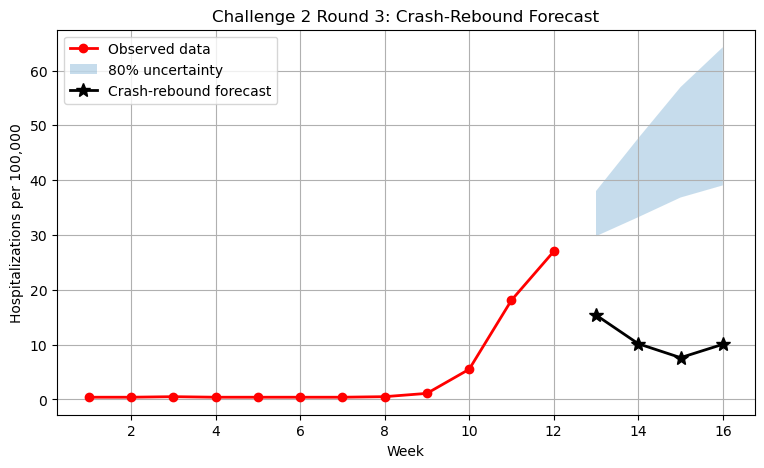

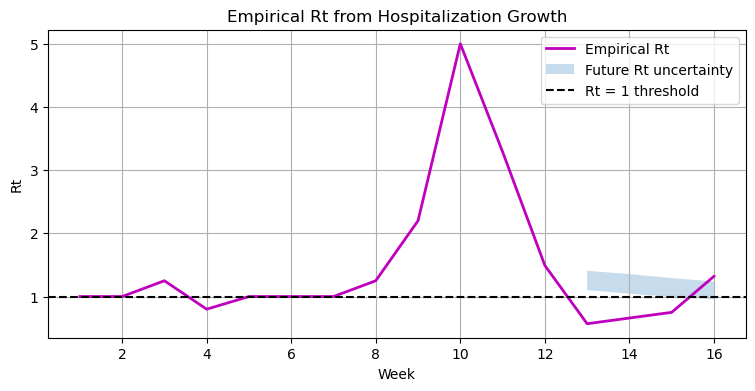


Challenge 2 Round 3 crash-rebound forecast generated successfully.


In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data2.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# CRASH-REBOUND TEMPLATE ONLY
# ============================================================

# ============================================================
# CRASH-THEN-REBOUND TEMPLATE
# ============================================================

current = hosp[-1]

crash_ratios = np.array([0.57, 0.66, 0.75, 1.32])

final_forecast = []

for r in crash_ratios:
    current = max(current * r, forecast_floor)
    final_forecast.append(current)

final_forecast = np.array(final_forecast)

# ============================================================
# EMPIRICAL Rt
# ============================================================

all_weeks = np.concatenate([week, future_weeks])
all_hosp = np.concatenate([hosp, final_forecast])

Rt_empirical = np.ones_like(all_hosp)

for i in range(1, len(all_hosp)):
    if all_hosp[i - 1] > 0:
        Rt_empirical[i] = all_hosp[i] / all_hosp[i - 1]
    else:
        Rt_empirical[i] = np.nan

Rt_future = Rt_empirical[-n_forecast:]

# ============================================================
# UNCERTAINTY ENSEMBLE
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))
Rt_ens = np.zeros((n_forecast, n_ens))

rebound_perturbation = 0.10

for j in range(n_ens):

    ratio_j = rebound_ratios * (1 + rebound_perturbation * rng.normal(size=n_forecast))
    ratio_j = np.clip(ratio_j, 0.80, 1.50)

    forecast_j = []
    current_j = hosp[-1]

    for r in ratio_j:
        current_j = max(current_j * r, forecast_floor)
        forecast_j.append(current_j)

    forecast_j = np.array(forecast_j)

    ensemble[:, j] = forecast_j

    all_hosp_j = np.concatenate([hosp, forecast_j])

    Rt_j = np.ones_like(all_hosp_j)

    for i in range(1, len(all_hosp_j)):
        if all_hosp_j[i - 1] > 0:
            Rt_j[i] = all_hosp_j[i] / all_hosp_j[i - 1]
        else:
            Rt_j[i] = np.nan

    Rt_ens[:, j] = Rt_j[-n_forecast:]

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

Rt_lower10 = np.percentile(Rt_ens, 10, axis=1)
Rt_median50 = np.percentile(Rt_ens, 50, axis=1)
Rt_upper90 = np.percentile(Rt_ens, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": all_weeks,
    "Hosp": all_hosp,
    "Rt": Rt_empirical
})

submission.to_csv("challenge2_round3_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
    "Rt_Lower10": Rt_lower10,
    "Rt_Median": Rt_median50,
    "Rt_Upper90": Rt_upper90
})

uncertainty.to_csv("challenge2_round3_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 ROUND 3: CRASH-REBOUND TEMPLATE =====")
print("Rebound ratios:", rebound_ratios)

print("\n===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====")
for w, h, rt, lo, hi in zip(
    future_weeks,
    final_forecast,
    Rt_future,
    lower10,
    upper90
):
    print(f"Week {int(w)}: Hosp={h:.4f}, Rt={rt:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT FORECAST
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Crash-rebound forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Round 3: Crash-Rebound Forecast")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT Rt
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(all_weeks, Rt_empirical, "m-", linewidth=2, label="Empirical Rt")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")

plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Empirical Rt from Hospitalization Growth")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_Rt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 Round 3 crash-rebound forecast generated successfully.")


===== CHALLENGE 2 ROUND 3: REBOUND FORECAST =====
Rebound ratios: [1.25 1.2  1.15 1.1 ]

===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====
Week 17: Hosp=12.5000, Rt=1.2500 [10.7360, 14.3967]
Week 18: Hosp=15.0000, Rt=1.2000 [11.8201, 18.2061]
Week 19: Hosp=17.2500, Rt=1.1500 [12.9649, 21.8870]
Week 20: Hosp=18.9750, Rt=1.1000 [13.5031, 24.8147]


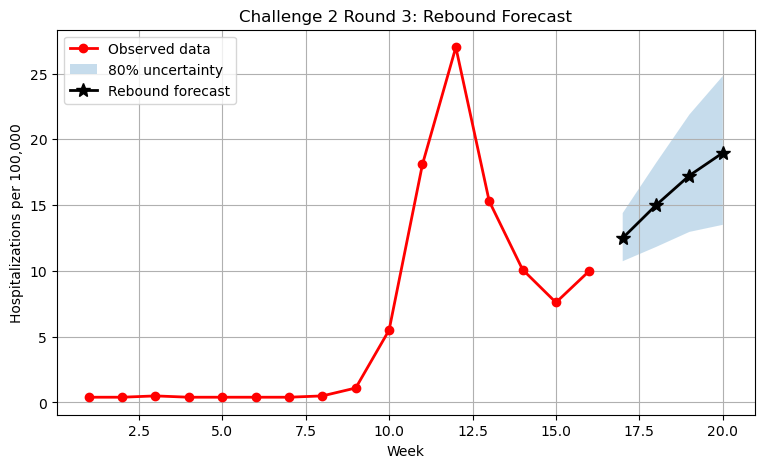

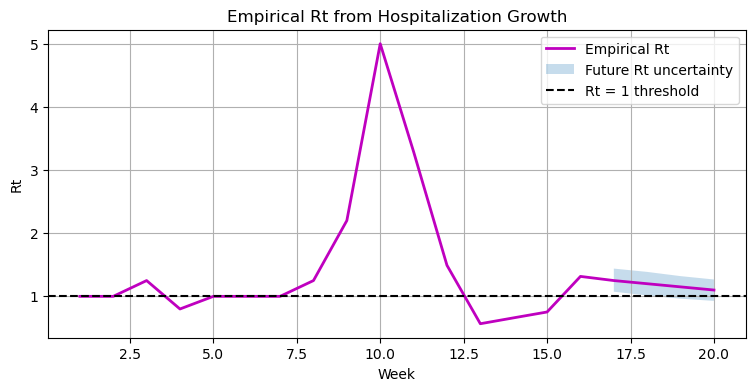


Challenge 2 Round 3 rebound forecast generated successfully.


In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data3.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# REBOUND TEMPLATE FORECAST
# ============================================================

rebound_ratios = np.array([1.25, 1.20, 1.15, 1.10])

current = hosp[-1]
final_forecast = []

for r in rebound_ratios:
    current = max(current * r, forecast_floor)
    final_forecast.append(current)

final_forecast = np.array(final_forecast)

# ============================================================
# EMPIRICAL Rt
# ============================================================

all_weeks = np.concatenate([week, future_weeks])
all_hosp = np.concatenate([hosp, final_forecast])

Rt_empirical = np.ones_like(all_hosp)

for i in range(1, len(all_hosp)):
    if all_hosp[i - 1] > 0:
        Rt_empirical[i] = all_hosp[i] / all_hosp[i - 1]
    else:
        Rt_empirical[i] = np.nan

Rt_future = Rt_empirical[-n_forecast:]

# ============================================================
# UNCERTAINTY
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))
Rt_ens = np.zeros((n_forecast, n_ens))

rebound_perturbation = 0.12

for j in range(n_ens):
    ratio_j = rebound_ratios * (1 + rebound_perturbation * rng.normal(size=n_forecast))
    ratio_j = np.clip(ratio_j, 0.85, 1.60)

    forecast_j = []
    current_j = hosp[-1]

    for r in ratio_j:
        current_j = max(current_j * r, forecast_floor)
        forecast_j.append(current_j)

    forecast_j = np.array(forecast_j)
    ensemble[:, j] = forecast_j

    all_hosp_j = np.concatenate([hosp, forecast_j])
    Rt_j = np.ones_like(all_hosp_j)

    for i in range(1, len(all_hosp_j)):
        if all_hosp_j[i - 1] > 0:
            Rt_j[i] = all_hosp_j[i] / all_hosp_j[i - 1]
        else:
            Rt_j[i] = np.nan

    Rt_ens[:, j] = Rt_j[-n_forecast:]

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

Rt_lower10 = np.percentile(Rt_ens, 10, axis=1)
Rt_median50 = np.percentile(Rt_ens, 50, axis=1)
Rt_upper90 = np.percentile(Rt_ens, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": all_weeks,
    "Hosp": all_hosp,
    "Rt": Rt_empirical
})

submission.to_csv("challenge2_round3_rebound_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
    "Rt_Lower10": Rt_lower10,
    "Rt_Median": Rt_median50,
    "Rt_Upper90": Rt_upper90
})

uncertainty.to_csv("challenge2_round3_rebound_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 ROUND 3: REBOUND FORECAST =====")
print("Rebound ratios:", rebound_ratios)

print("\n===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====")
for w, h, rt, lo, hi in zip(
    future_weeks,
    final_forecast,
    Rt_future,
    lower10,
    upper90
):
    print(f"Week {int(w)}: Hosp={h:.4f}, Rt={rt:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT FORECAST
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Rebound forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Round 3: Rebound Forecast")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_rebound_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT Rt
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(all_weeks, Rt_empirical, "m-", linewidth=2, label="Empirical Rt")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")

plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Empirical Rt from Hospitalization Growth")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_rebound_Rt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 Round 3 rebound forecast generated successfully.")


===== CHALLENGE 2 ROUND 3: BLENDED REBOUND-PLATEAU FORECAST =====
Rebound ratios: [1.15 1.12 1.08 1.05]
Plateau ratios: [1.05 1.03 1.02 1.  ]

===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====
Week 17: Hosp=11.1500, Rt=1.1150 [10.3323, 11.9474]
Week 18: Hosp=12.1573, Rt=1.0903 [10.9569, 13.5215]
Week 19: Hosp=12.9027, Rt=1.0613 [11.3400, 14.6716]
Week 20: Hosp=13.3548, Rt=1.0350 [11.4637, 15.4573]


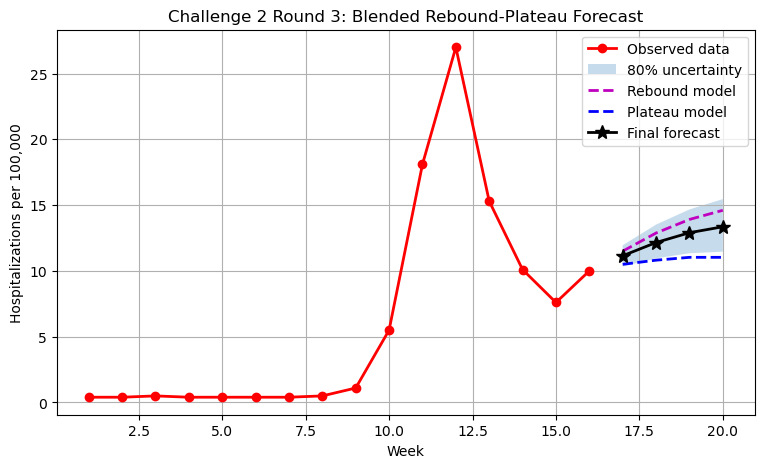

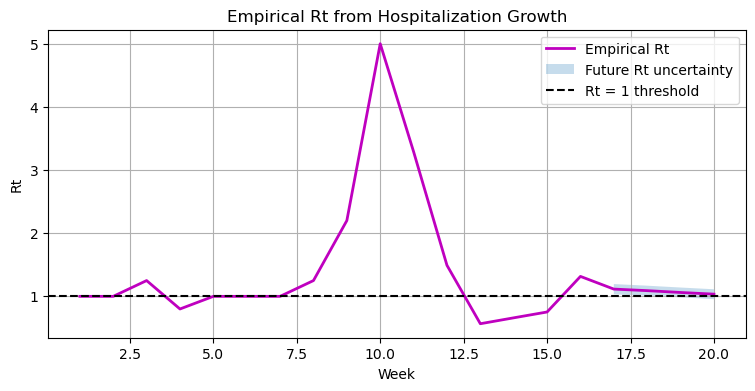


Challenge 2 Round 3 blended rebound-plateau forecast generated successfully.


In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data3.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# CONSERVATIVE REBOUND MODEL
# ============================================================

rebound_ratios = np.array([1.15, 1.12, 1.08, 1.05])

current = hosp[-1]
rebound_forecast = []

for r in rebound_ratios:
    current = max(current * r, forecast_floor)
    rebound_forecast.append(current)

rebound_forecast = np.array(rebound_forecast)

# ============================================================
# PLATEAU MODEL
# ============================================================

plateau_ratios = np.array([1.05, 1.03, 1.02, 1.00])

current = hosp[-1]
plateau_forecast = []

for r in plateau_ratios:
    current = max(current * r, forecast_floor)
    plateau_forecast.append(current)

plateau_forecast = np.array(plateau_forecast)

# ============================================================
# FINAL FORECAST: BLENDED REBOUND + PLATEAU
# ============================================================

final_forecast = (
    0.65 * rebound_forecast
    + 0.35 * plateau_forecast
)

final_forecast = np.maximum(final_forecast, forecast_floor)

# ============================================================
# EMPIRICAL Rt
# ============================================================

all_weeks = np.concatenate([week, future_weeks])
all_hosp = np.concatenate([hosp, final_forecast])

Rt_empirical = np.ones_like(all_hosp)

for i in range(1, len(all_hosp)):
    if all_hosp[i - 1] > 0:
        Rt_empirical[i] = all_hosp[i] / all_hosp[i - 1]
    else:
        Rt_empirical[i] = np.nan

Rt_future = Rt_empirical[-n_forecast:]

# ============================================================
# UNCERTAINTY
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))
Rt_ens = np.zeros((n_forecast, n_ens))

rebound_perturbation = 0.08
plateau_perturbation = 0.05

for j in range(n_ens):

    rebound_ratio_j = rebound_ratios * (
        1 + rebound_perturbation * rng.normal(size=n_forecast)
    )
    rebound_ratio_j = np.clip(rebound_ratio_j, 0.90, 1.35)

    current_j = hosp[-1]
    rebound_j = []

    for r in rebound_ratio_j:
        current_j = max(current_j * r, forecast_floor)
        rebound_j.append(current_j)

    rebound_j = np.array(rebound_j)

    plateau_ratio_j = plateau_ratios * (
        1 + plateau_perturbation * rng.normal(size=n_forecast)
    )
    plateau_ratio_j = np.clip(plateau_ratio_j, 0.90, 1.20)

    current_j = hosp[-1]
    plateau_j = []

    for r in plateau_ratio_j:
        current_j = max(current_j * r, forecast_floor)
        plateau_j.append(current_j)

    plateau_j = np.array(plateau_j)

    forecast_j = (
        0.65 * rebound_j
        + 0.35 * plateau_j
    )

    ensemble[:, j] = np.maximum(forecast_j, forecast_floor)

    all_hosp_j = np.concatenate([hosp, ensemble[:, j]])

    Rt_j = np.ones_like(all_hosp_j)

    for i in range(1, len(all_hosp_j)):
        if all_hosp_j[i - 1] > 0:
            Rt_j[i] = all_hosp_j[i] / all_hosp_j[i - 1]
        else:
            Rt_j[i] = np.nan

    Rt_ens[:, j] = Rt_j[-n_forecast:]

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

Rt_lower10 = np.percentile(Rt_ens, 10, axis=1)
Rt_median50 = np.percentile(Rt_ens, 50, axis=1)
Rt_upper90 = np.percentile(Rt_ens, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": all_weeks,
    "Hosp": all_hosp,
    "Rt": Rt_empirical
})

submission.to_csv("challenge2_round3_blended_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
    "Rt_Lower10": Rt_lower10,
    "Rt_Median": Rt_median50,
    "Rt_Upper90": Rt_upper90
})

uncertainty.to_csv("challenge2_round3_blended_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 ROUND 3: BLENDED REBOUND-PLATEAU FORECAST =====")
print("Rebound ratios:", rebound_ratios)
print("Plateau ratios:", plateau_ratios)

print("\n===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====")
for w, h, rt, lo, hi in zip(
    future_weeks,
    final_forecast,
    Rt_future,
    lower10,
    upper90
):
    print(f"Week {int(w)}: Hosp={h:.4f}, Rt={rt:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT FORECAST
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, rebound_forecast, "m--", linewidth=2, label="Rebound model")
plt.plot(future_weeks, plateau_forecast, "b--", linewidth=2, label="Plateau model")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Final forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Round 3: Blended Rebound-Plateau Forecast")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_blended_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT Rt
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(all_weeks, Rt_empirical, "m-", linewidth=2, label="Empirical Rt")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")

plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Empirical Rt from Hospitalization Growth")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_blended_Rt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 Round 3 blended rebound-plateau forecast generated successfully.")


===== CHALLENGE 2 ROUND 3: REBOUND-THEN-DECLINE FORECAST =====
Forecast ratios: [1.29 0.64 0.9  0.5 ]

===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====
Week 17: Hosp=12.9000, Rt=1.2900 [11.6864, 14.2049]
Week 18: Hosp=8.2560, Rt=0.6400 [7.0651, 9.4158]
Week 19: Hosp=7.4304, Rt=0.9000 [6.1702, 8.7552]
Week 20: Hosp=3.7152, Rt=0.5000 [3.0037, 4.4637]


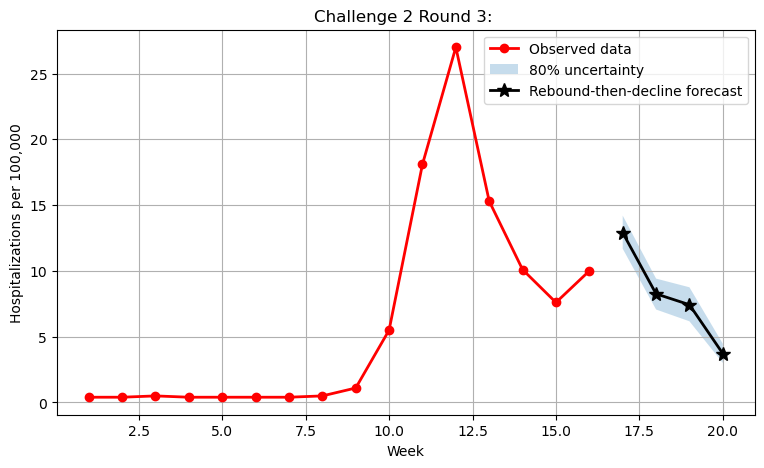

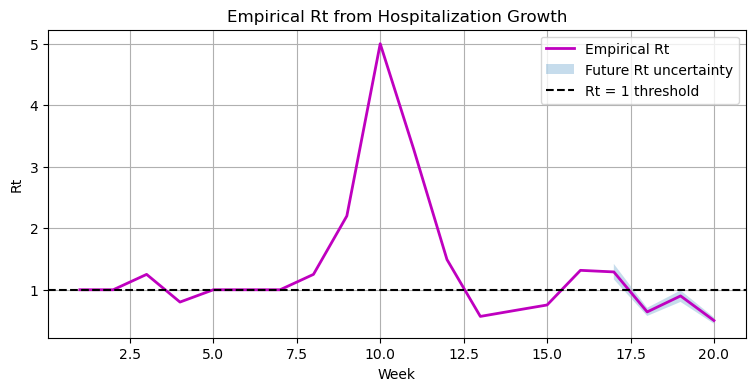


Challenge 2 Round 3 rebound-then-decline forecast generated successfully.


In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data3.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# REBOUND-THEN-DECLINE TEMPLATE
# ============================================================

forecast_ratios = np.array([1.29, 0.64, 0.9, 0.5])

current = hosp[-1]
final_forecast = []

for r in forecast_ratios:
    current = max(current * r, forecast_floor)
    final_forecast.append(current)

final_forecast = np.array(final_forecast)

# ============================================================
# EMPIRICAL Rt
# ============================================================

all_weeks = np.concatenate([week, future_weeks])
all_hosp = np.concatenate([hosp, final_forecast])

Rt_empirical = np.ones_like(all_hosp)

for i in range(1, len(all_hosp)):
    if all_hosp[i - 1] > 0:
        Rt_empirical[i] = all_hosp[i] / all_hosp[i - 1]
    else:
        Rt_empirical[i] = np.nan

Rt_future = Rt_empirical[-n_forecast:]

# ============================================================
# UNCERTAINTY
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))
Rt_ens = np.zeros((n_forecast, n_ens))

ratio_perturbation = 0.08

for j in range(n_ens):
    ratio_j = forecast_ratios * (1 + ratio_perturbation * rng.normal(size=n_forecast))
    ratio_j = np.clip(ratio_j, 0.35, 1.50)

    forecast_j = []
    current_j = hosp[-1]

    for r in ratio_j:
        current_j = max(current_j * r, forecast_floor)
        forecast_j.append(current_j)

    forecast_j = np.array(forecast_j)
    ensemble[:, j] = forecast_j

    all_hosp_j = np.concatenate([hosp, forecast_j])

    Rt_j = np.ones_like(all_hosp_j)

    for i in range(1, len(all_hosp_j)):
        if all_hosp_j[i - 1] > 0:
            Rt_j[i] = all_hosp_j[i] / all_hosp_j[i - 1]
        else:
            Rt_j[i] = np.nan

    Rt_ens[:, j] = Rt_j[-n_forecast:]

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

Rt_lower10 = np.percentile(Rt_ens, 10, axis=1)
Rt_median50 = np.percentile(Rt_ens, 50, axis=1)
Rt_upper90 = np.percentile(Rt_ens, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": all_weeks,
    "Hosp": all_hosp,
    "Rt": Rt_empirical
})

submission.to_csv("challenge2_round3_decline_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
    "Rt_Lower10": Rt_lower10,
    "Rt_Median": Rt_median50,
    "Rt_Upper90": Rt_upper90
})

uncertainty.to_csv("challenge2_round3_decline_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 ROUND 3: REBOUND-THEN-DECLINE FORECAST =====")
print("Forecast ratios:", forecast_ratios)

print("\n===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====")
for w, h, rt, lo, hi in zip(
    future_weeks,
    final_forecast,
    Rt_future,
    lower10,
    upper90
):
    print(f"Week {int(w)}: Hosp={h:.4f}, Rt={rt:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT FORECAST
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Rebound-then-decline forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Round 3: ")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_decline_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT Rt
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(all_weeks, Rt_empirical, "m-", linewidth=2, label="Empirical Rt")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")

plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Empirical Rt from Hospitalization Growth")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_decline_Rt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 Round 3 rebound-then-decline forecast generated successfully.")


===== CHALLENGE 2 ROUND 3: REBOUND-THEN-DECLINE FORECAST =====
Forecast ratios: [0.55 0.6  0.7  0.85]

===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====
Week 21: Hosp=1.5400, Rt=0.5500 [1.3951, 1.6958]
Week 22: Hosp=0.9240, Rt=0.6000 [0.7907, 1.0584]
Week 23: Hosp=0.6468, Rt=0.7000 [0.5371, 0.7627]
Week 24: Hosp=0.5498, Rt=0.8500 [0.4445, 0.6615]


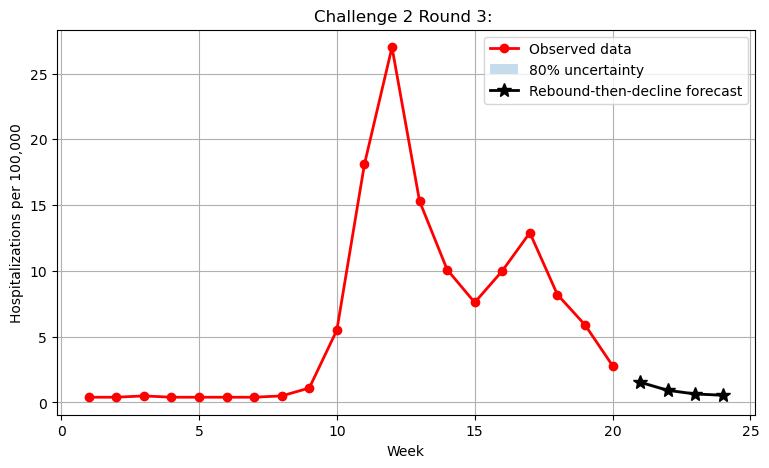

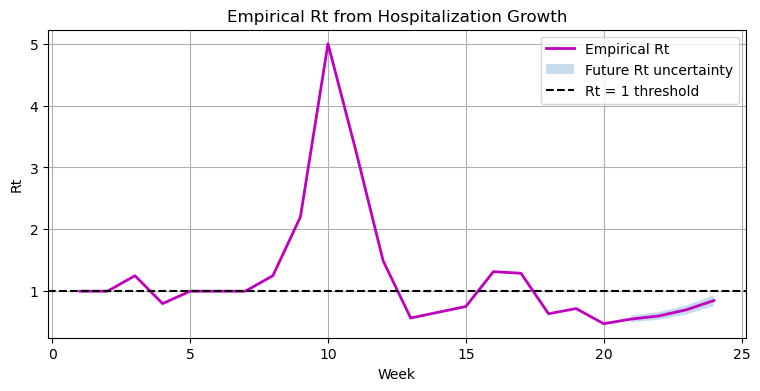


Challenge 2 Round 3 rebound-then-decline forecast generated successfully.


In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data4.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.01

# ============================================================
# REBOUND-THEN-DECLINE TEMPLATE
# ============================================================

forecast_ratios = np.array([0.55, 0.60, 0.70, 0.85])

current = hosp[-1]
final_forecast = []

for r in forecast_ratios:
    current = max(current * r, forecast_floor)
    final_forecast.append(current)

final_forecast = np.array(final_forecast)

# ============================================================
# EMPIRICAL Rt
# ============================================================

all_weeks = np.concatenate([week, future_weeks])
all_hosp = np.concatenate([hosp, final_forecast])

Rt_empirical = np.ones_like(all_hosp)

for i in range(1, len(all_hosp)):
    if all_hosp[i - 1] > 0:
        Rt_empirical[i] = all_hosp[i] / all_hosp[i - 1]
    else:
        Rt_empirical[i] = np.nan

Rt_future = Rt_empirical[-n_forecast:]

# ============================================================
# UNCERTAINTY
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))
Rt_ens = np.zeros((n_forecast, n_ens))

ratio_perturbation = 0.08

for j in range(n_ens):
    ratio_j = forecast_ratios * (1 + ratio_perturbation * rng.normal(size=n_forecast))
    ratio_j = np.clip(ratio_j, 0.35, 1.50)

    forecast_j = []
    current_j = hosp[-1]

    for r in ratio_j:
        current_j = max(current_j * r, forecast_floor)
        forecast_j.append(current_j)

    forecast_j = np.array(forecast_j)
    ensemble[:, j] = forecast_j

    all_hosp_j = np.concatenate([hosp, forecast_j])

    Rt_j = np.ones_like(all_hosp_j)

    for i in range(1, len(all_hosp_j)):
        if all_hosp_j[i - 1] > 0:
            Rt_j[i] = all_hosp_j[i] / all_hosp_j[i - 1]
        else:
            Rt_j[i] = np.nan

    Rt_ens[:, j] = Rt_j[-n_forecast:]

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

Rt_lower10 = np.percentile(Rt_ens, 10, axis=1)
Rt_median50 = np.percentile(Rt_ens, 50, axis=1)
Rt_upper90 = np.percentile(Rt_ens, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": all_weeks,
    "Hosp": all_hosp,
    "Rt": Rt_empirical
})

submission.to_csv("challenge2_round3_decline_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
    "Rt_Lower10": Rt_lower10,
    "Rt_Median": Rt_median50,
    "Rt_Upper90": Rt_upper90
})

uncertainty.to_csv("challenge2_round3_decline_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 ROUND 3: REBOUND-THEN-DECLINE FORECAST =====")
print("Forecast ratios:", forecast_ratios)

print("\n===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====")
for w, h, rt, lo, hi in zip(
    future_weeks,
    final_forecast,
    Rt_future,
    lower10,
    upper90
):
    print(f"Week {int(w)}: Hosp={h:.4f}, Rt={rt:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT FORECAST
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Rebound-then-decline forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Round 3: ")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_decline_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT Rt
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(all_weeks, Rt_empirical, "m-", linewidth=2, label="Empirical Rt")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")

plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Empirical Rt from Hospitalization Growth")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round3_decline_Rt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 Round 3 rebound-then-decline forecast generated successfully.")


===== CHALLENGE 2 ROUND 4: DECLINE-FLATTENING FORECAST =====
Decline ratios: [0.65 0.8  0.88 0.92]
Rebound-protection ratios: [0.9  1.   1.05 1.  ]

===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====
Week 21: Hosp=1.9600, Rt=0.7000 [1.8435, 2.2173]
Week 22: Hosp=1.6688, Rt=0.8514 [1.5624, 2.0134]
Week 23: Hosp=1.5542, Rt=0.9313 [1.4236, 1.9643]
Week 24: Hosp=1.4722, Rt=0.9472 [1.3333, 1.9251]


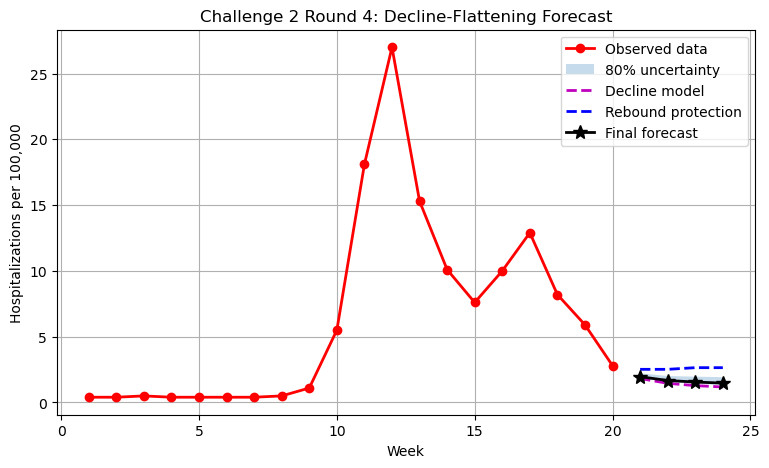

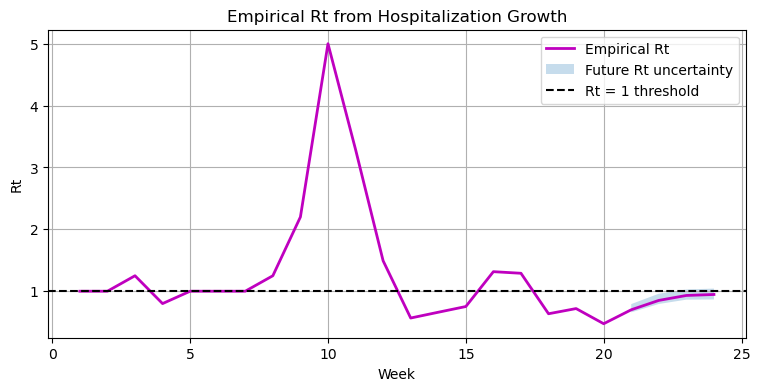


Challenge 2 Round 4 decline-flattening forecast generated successfully.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("report_figures", exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(r"C:\Users\sunsp\Downloads\chan2data4.csv")

week = data["Week"].to_numpy(dtype=float)
hosp = data["Hosp"].to_numpy(dtype=float)

n_forecast = 4
future_weeks = np.arange(week[-1] + 1, week[-1] + n_forecast + 1)

forecast_floor = 0.4

# ============================================================
# DECLINE + FLATTENING TEMPLATE
# ============================================================

forecast_ratios = np.array([0.65, 0.80, 0.88, 0.92])
forecast_floor = 0.4

current = hosp[-1]
decline_forecast = []

for r in forecast_ratios:
    current = max(current * r, forecast_floor)
    decline_forecast.append(current)

decline_forecast = np.array(decline_forecast)

# Small rebound protection
current = hosp[-1]
rebound_ratios = np.array([0.90, 1.00, 1.05, 1.00])

rebound_forecast = []

for r in rebound_ratios:
    current = max(current * r, forecast_floor)
    rebound_forecast.append(current)

rebound_forecast = np.array(rebound_forecast)

# Final blended forecast
final_forecast = (
    0.70 * decline_forecast
    + 0.30 * rebound_forecast
)

final_forecast = np.maximum(final_forecast, forecast_floor)
final_forecast = 0.80 * decline_forecast + 0.20 * rebound_forecast

# ============================================================
# EMPIRICAL Rt
# ============================================================

all_weeks = np.concatenate([week, future_weeks])
all_hosp = np.concatenate([hosp, final_forecast])

Rt_empirical = np.ones_like(all_hosp)

for i in range(1, len(all_hosp)):
    if all_hosp[i - 1] > 0:
        Rt_empirical[i] = all_hosp[i] / all_hosp[i - 1]
    else:
        Rt_empirical[i] = np.nan

Rt_future = Rt_empirical[-n_forecast:]

# ============================================================
# UNCERTAINTY
# ============================================================

n_ens = 500
rng = np.random.default_rng(1)

ensemble = np.zeros((n_forecast, n_ens))
Rt_ens = np.zeros((n_forecast, n_ens))

ratio_perturbation = 0.10

for j in range(n_ens):
    decline_ratio_j = forecast_ratios * (1 + ratio_perturbation * rng.normal(size=n_forecast))
    decline_ratio_j = np.clip(decline_ratio_j, 0.50, 1.10)

    current_j = hosp[-1]
    decline_j = []

    for r in decline_ratio_j:
        current_j = max(current_j * r, forecast_floor)
        decline_j.append(current_j)

    decline_j = np.array(decline_j)

    rebound_ratio_j = rebound_ratios * (1 + ratio_perturbation * rng.normal(size=n_forecast))
    rebound_ratio_j = np.clip(rebound_ratio_j, 0.70, 1.20)

    current_j = hosp[-1]
    rebound_j = []

    for r in rebound_ratio_j:
        current_j = max(current_j * r, forecast_floor)
        rebound_j.append(current_j)

    rebound_j = np.array(rebound_j)

    forecast_j = 0.70 * decline_j + 0.30 * rebound_j
    ensemble[:, j] = np.maximum(forecast_j, forecast_floor)

    all_hosp_j = np.concatenate([hosp, ensemble[:, j]])
    Rt_j = np.ones_like(all_hosp_j)

    for i in range(1, len(all_hosp_j)):
        if all_hosp_j[i - 1] > 0:
            Rt_j[i] = all_hosp_j[i] / all_hosp_j[i - 1]
        else:
            Rt_j[i] = np.nan

    Rt_ens[:, j] = Rt_j[-n_forecast:]

lower10 = np.percentile(ensemble, 10, axis=1)
median50 = np.percentile(ensemble, 50, axis=1)
upper90 = np.percentile(ensemble, 90, axis=1)

Rt_lower10 = np.percentile(Rt_ens, 10, axis=1)
Rt_median50 = np.percentile(Rt_ens, 50, axis=1)
Rt_upper90 = np.percentile(Rt_ens, 90, axis=1)

# ============================================================
# EXPORT FILES
# ============================================================

submission = pd.DataFrame({
    "Week": all_weeks,
    "Hosp": all_hosp,
    "Rt": Rt_empirical
})

submission.to_csv("challenge2_round4_submission.csv", index=False)

uncertainty = pd.DataFrame({
    "Week": future_weeks,
    "Lower10": lower10,
    "Median": median50,
    "Upper90": upper90,
    "Rt_Lower10": Rt_lower10,
    "Rt_Median": Rt_median50,
    "Rt_Upper90": Rt_upper90
})

uncertainty.to_csv("challenge2_round4_uncertainty.csv", index=False)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n===== CHALLENGE 2 ROUND 4: DECLINE-FLATTENING FORECAST =====")
print("Decline ratios:", forecast_ratios)
print("Rebound-protection ratios:", rebound_ratios)

print("\n===== 4-WEEK FORECAST WITH EMPIRICAL Rt =====")
for w, h, rt, lo, hi in zip(
    future_weeks,
    final_forecast,
    Rt_future,
    lower10,
    upper90
):
    print(f"Week {int(w)}: Hosp={h:.4f}, Rt={rt:.4f} [{lo:.4f}, {hi:.4f}]")

# ============================================================
# PLOT FORECAST
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(week, hosp, "ro-", linewidth=2, label="Observed data")
plt.fill_between(future_weeks, lower10, upper90, alpha=0.25, label="80% uncertainty")
plt.plot(future_weeks, decline_forecast, "m--", linewidth=2, label="Decline model")
plt.plot(future_weeks, rebound_forecast, "b--", linewidth=2, label="Rebound protection")
plt.plot(future_weeks, final_forecast, "k*-", linewidth=2, markersize=10, label="Final forecast")

plt.xlabel("Week")
plt.ylabel("Hospitalizations per 100,000")
plt.title("Challenge 2 Round 4: Decline-Flattening Forecast")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round4_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# PLOT Rt
# ============================================================

plt.figure(figsize=(9, 4))

plt.plot(all_weeks, Rt_empirical, "m-", linewidth=2, label="Empirical Rt")
plt.fill_between(future_weeks, Rt_lower10, Rt_upper90, alpha=0.25, label="Future Rt uncertainty")
plt.axhline(1, color="black", linestyle="--", label="Rt = 1 threshold")

plt.xlabel("Week")
plt.ylabel("Rt")
plt.title("Empirical Rt from Hospitalization Growth")
plt.legend()
plt.grid(True)

plt.savefig("report_figures/Challenge2_round4_Rt.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nChallenge 2 Round 4 decline-flattening forecast generated successfully.")